# All results analyzer

In this notebook, we will analyze all the results from the parameter tuning experiments for deterministic optimization (det_opt), simulation last heuristic (sim_last), standard simheuristic (std_simh) and dynamic simheuristics (dyn_simh). In particular, we are interested in finding out about understanding when det_opt and sim_last are effective and when simheuristics std_simh and dyn_simh and also the sensitivity of those methods.

## Naming convention

This notebook uses legacy variable names that differ from the project-wide naming convention. The mapping is:

| Variable in this notebook | Meaning                                                           | Project convention   |
|---|-------------------------------------------------------------------|----------------------|
| `problem_name` | Scheduling problem (e.g. `JobShop`, `OpenShop`)                     | **problem class**    |
| `problem_type` | Class + stochasticity + tardiness (e.g. `JobShopFullStochNoTard`) | **problem variant**  |
| `(problem_type, seed)` | A fully specified, solvable case                                  | **problem instance** |

## Load data

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../results")
EXP_GROUP_ORDER = [
    "p = 0.3 | no_tardiness",
    "p = 1.0 | no_tardiness",
    "p = 0.3 | with_tardiness",
    "p = 1.0 | with_tardiness",
]

# all_csv_files is copied from param_tuning_X.ipynb for x = det_opt, dyn_simh, sim_last and std_simh, respectively
all_csv_files = """FlexibleJobShop_2025-06-14_18-03-57.csv
FlexibleJobShopFullStoch_2025-06-14_18-04-15.csv
HybridFlowShop_2025-06-14_18-04-25.csv
HybridFlowShopFullStoch_2025-06-14_18-04-36.csv
JobShop_2025-06-14_18-05-00.csv
JobShopFullStoch_2025-06-14_18-04-53.csv
OpenShop_2025-06-14_18-03-30.csv
OpenShopFullStoch_2025-06-14_18-03-54.csv
ParallelMachines_2025-06-14_18-05-20.csv
ParallelMachinesFullStoch_2025-06-14_18-05-12.csv
HybridFlowShopFullStochNoTard_2025-06-15_08-47-09.csv
HybridFlowShopNoTard_2025-06-15_08-46-51.csv
ParallelMachinesFullStochNoTard_2025-06-15_08-47-24.csv
ParallelMachinesNoTard_2025-06-15_08-47-22.csv
OpenShopFullStochNoTard_2025-06-15_08-46-47.csv
OpenShopNoTard_2025-06-15_08-46-47.csv
JobShopFullStochNoTard_2025-06-15_08-47-09.csv
FlexibleJobShopFullStochNoTard_2025-06-15_08-46-47.csv
JobShopNoTard_2025-06-15_08-47-09.csv
FlexibleJobShopNoTard_2025-06-15_08-46-47.csv
JobShopFullStoch_2025-07-02_20-34-55.csv
JobShopFullStochNoTard_2025-07-02_20-35-06.csv
JobShopNoTard_2025-07-02_20-35-03.csv
FlexibleJobShopFullStochNoTard_2025-07-02_20-34-29.csv
JobShop_2025-07-02_20-34-49.csv
FlexibleJobShopFullStoch_2025-07-02_20-34-18.csv
FlexibleJobShop_2025-07-02_20-34-06.csv
FlexibleJobShopNoTard_2025-07-02_20-34-18.csv
ParallelMachinesFullStoch_2025-07-02_20-35-18.csv
ParallelMachinesFullStochNoTard_2025-07-02_20-35-28.csv
ParallelMachinesNoTard_2025-07-02_20-35-22.csv
HybridFlowShopFullStochNoTard_2025-07-02_20-34-52.csv
ParallelMachines_2025-07-02_20-35-13.csv
HybridFlowShopFullStoch_2025-07-02_20-34-31.csv
HybridFlowShopNoTard_2025-07-02_20-34-37.csv
HybridFlowShop_2025-07-02_20-34-28.csv
OpenShopFullStochNoTard_2025-07-02_20-34-00.csv
OpenShopNoTard_2025-07-02_20-33-54.csv
OpenShopFullStoch_2025-07-02_20-33-50.csv
OpenShop_2025-07-02_20-33-45.csv
JobShopFullStoch_2025-06-15_11-46-14.csv
FlexibleJobShopFullStochNoTard_2025-06-15_11-45-42.csv
JobShop_2025-06-15_11-46-08.csv
FlexibleJobShop_2025-06-15_11-45-30.csv
FlexibleJobShopNoTard_2025-06-15_11-45-38.csv
ParallelMachinesFullStoch_2025-06-15_11-46-38.csv
ParallelMachinesFullStochNoTard_2025-06-15_11-46-49.csv
ParallelMachinesNoTard_2025-06-15_11-46-43.csv
HybridFlowShopFullStochNoTard_2025-06-15_11-46-03.csv
ParallelMachines_2025-06-15_11-46-32.csv
HybridFlowShopFullStoch_2025-06-15_11-45-53.csv
HybridFlowShopNoTard_2025-06-15_11-45-57.csv
HybridFlowShop_2025-06-15_11-45-46.csv
OpenShopFullStochNoTard_2025-06-15_11-45-18.csv
OpenShopFullStoch_2025-06-15_11-45-10.csv
OpenShopNoTard_2025-06-15_11-45-17.csv
OpenShop_2025-06-15_11-45-04.csv
JobShopFullStochNoTard_2025-06-15_11-46-32.csv
JobShopNoTard_2025-06-15_11-46-26.csv
FlexibleJobShopFullStoch_2025-06-15_11-45-30.csv
HybridFlowShopNoTard_2025-06-29_16-18-25.csv
ParallelMachines_2025-06-29_16-19-04.csv
ParallelMachinesNoTard_2025-06-29_16-19-26.csv
HybridFlowShop_2025-06-29_16-18-22.csv
HybridFlowShopFullStoch_2025-06-29_16-18-21.csv
OpenShopFullStoch_2025-06-29_16-17-32.csv
OpenShopFullStochNoTard_2025-06-29_16-17-47.csv
OpenShopNoTard_2025-06-29_16-17-38.csv
JobShopFullStochNoTard_2025-06-29_16-18-56.csv
OpenShop_2025-06-29_16-17-27.csv
JobShopNoTard_2025-06-29_16-18-56.csv
FlexibleJobShopFullStoch_2025-06-29_16-17-56.csv
FlexibleJobShopFullStochNoTard_2025-06-29_16-18-10.csv
JobShop_2025-06-29_16-18-37.csv
FlexibleJobShop_2025-06-29_16-17-47.csv
JobShopFullStoch_2025-06-29_16-18-46.csv
FlexibleJobShopNoTard_2025-06-29_16-18-10.csv
ParallelMachinesFullStoch_2025-06-29_16-19-06.csv
ParallelMachinesFullStochNoTard_2025-06-29_16-19-26.csv
HybridFlowShopFullStochNoTard_2025-06-29_16-18-37.csv""".split('\n')
problem_order = ['OpenShop', 'ParallelMachines', 'HybridFlowShop', 'JobShop', 'FlexibleJobShop']

def find_with_part(file_names, part):
    """Find all file names that contain a specific part."""
    return [name for name in file_names if part == name.split('_')[0]]

def build_file_names_per_exp_group(file_names):
    """Build all 4 experiment groups in a fixed order."""
    return {
        "p = 0.3 | no_tardiness": [
            file_name
            for problem_name in problem_order
            for file_name in find_with_part(file_names, problem_name + "NoTard")
            ],
        "p = 1.0 | no_tardiness": [
            file_name
            for problem_name in problem_order
            for file_name in find_with_part(file_names, problem_name + "FullStochNoTard")
            ],
        "p = 0.3 | with_tardiness": [
            file_name
            for problem_name in problem_order
            for file_name in find_with_part(file_names, problem_name)
        ],
        "p = 1.0 | with_tardiness": [
            file_name
            for problem_name in problem_order
            for file_name in find_with_part(file_names, problem_name + "FullStoch")
        ]
    }

def problem_type_for_group(problem_name, exp_group):
    """Find the problem type for a problem in a specific experiment group."""
    is_full_stoch = "p = 1.0" in exp_group
    with_tardiness = "with_tardiness" in exp_group
    suffix = ("FullStoch" if is_full_stoch else "") + ("" if with_tardiness else "NoTard")
    return problem_name + suffix

file_names_per_exp_group = build_file_names_per_exp_group(all_csv_files)

# in experiments for sim last heuristic, we forgot to change the name, so we need to add it manually
correct_sim_last_names = [f"sim_last_{i + 1}" for j in range(20) for i in range(8)]
all_csv_files_sim_last = """JobShopFullStoch_2025-06-15_11-46-14.csv
FlexibleJobShopFullStochNoTard_2025-06-15_11-45-42.csv
JobShop_2025-06-15_11-46-08.csv
FlexibleJobShop_2025-06-15_11-45-30.csv
FlexibleJobShopNoTard_2025-06-15_11-45-38.csv
ParallelMachinesFullStoch_2025-06-15_11-46-38.csv
ParallelMachinesFullStochNoTard_2025-06-15_11-46-49.csv
ParallelMachinesNoTard_2025-06-15_11-46-43.csv
HybridFlowShopFullStochNoTard_2025-06-15_11-46-03.csv
ParallelMachines_2025-06-15_11-46-32.csv
HybridFlowShopFullStoch_2025-06-15_11-45-53.csv
HybridFlowShopNoTard_2025-06-15_11-45-57.csv
HybridFlowShop_2025-06-15_11-45-46.csv
OpenShopFullStochNoTard_2025-06-15_11-45-18.csv
OpenShopFullStoch_2025-06-15_11-45-10.csv
OpenShopNoTard_2025-06-15_11-45-17.csv
OpenShop_2025-06-15_11-45-04.csv
JobShopFullStochNoTard_2025-06-15_11-46-32.csv
JobShopNoTard_2025-06-15_11-46-26.csv
FlexibleJobShopFullStoch_2025-06-15_11-45-30.csv""".split('\n')

# Store all experiments in one large dataframe with appropriate labeling
all_rows = []
for exp_group, file_names in file_names_per_exp_group.items():
    for file_name in file_names:
        df = pd.read_csv(DATA_DIR / file_name)
        if file_name in all_csv_files_sim_last:
            df["simheuristic"] = correct_sim_last_names  # I forgot to change the name
        df["exp_group"] = exp_group
        df["with_tardiness"] = "with_tardiness" in exp_group
        df["full_stoch"] = "p = 1.0" in exp_group
        all_rows.append(df)
df_all = pd.concat(all_rows, ignore_index=True)
df_all["exp_group"] = pd.Categorical(df_all["exp_group"], categories=EXP_GROUP_ORDER, ordered=True)
display(df_all.head(5))

,project_name,problem_type,simheuristic,seed,mean,std,num_sims,DCOP_objective,DCOP_solution,callback_log,solve status,solver_phase_dur,final_sim_phase_dur,total_exp_dur,exp_group,with_tardiness,full_stoch
0,OpenShopNoTard_2025-06-15_08-46-47,OpenShopNoTard,det_opt_1,0,7926.412,196.203181,1000,7406.0,"{""tasks"": [{""mode"": 0, ""resources"": [0, 5], ""s...",\nCallback Log:\n-----------------------------...,Feasible,300.180793,0.000106,300.180899,p = 0.3 | no_tardiness,False,False
1,OpenShopNoTard_2025-06-15_08-46-47,OpenShopNoTard,det_opt_2,0,7873.390,176.874831,1000,7459.0,"{""tasks"": [{""mode"": 0, ""resources"": [0, 5], ""s...",\nCallback Log:\n-----------------------------...,Feasible,300.254351,0.000037,300.254388,p = 0.3 | no_tardiness,False,False
2,OpenShopNoTard_2025-06-15_08-46-47,OpenShopNoTard,det_opt_3,0,7899.506,152.373311,1000,7582.0,"{""tasks"": [{""mode"": 0, ""resources"": [0, 5], ""s...",\nCallback Log:\n-----------------------------...,Feasible,300.198841,0.000105,300.198946,p = 0.3 | no_tardiness,False,False
3,OpenShopNoTard_2025-06-15_08-46-47,OpenShopNoTard,det_opt_4,0,7918.952,109.081198,1000,7726.0,"{""tasks"": [{""mode"": 0, ""resources"": [0, 5], ""s...",\nCallback Log:\n-----------------------------...,Feasible,300.304887,0.000037,300.304924,p = 0.3 | no_tardiness,False,False
4,OpenShopNoTard_2025-06-15_08-46-47,OpenShopNoTard,det_opt_1,1,8621.916,202.103654,1000,8080.0,"{""tasks"": [{""mode"": 0, ""resources"": [0, 5], ""s...",\nCallback Log:\n-----------------------------...,Feasible,300.286780,0.000050,300.286830,p = 0.3 | no_tardiness,False,False


# Feature engineering

This section computes all derived features and caches intermediate
results (e.g. parsed callback logs) so that downstream cells never
need to repeat expensive parsing.

## Helper functions

Utility functions used throughout the notebook. Defined once here
so they are available in every subsequent cell.

In [2]:
import numpy as np
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st_stats
from collections import defaultdict
from scipy.stats import spearmanr, shapiro, ttest_rel as _ttest_rel
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from matplotlib.colors import ListedColormap


def parse_callback_log(log_text: str):
    """
    Parse a callback log string and return:
    - total number of 'New unique schedule' events
    - total number of 'Duplicate schedule' events
    - list of timestamps (in seconds) at which new unique schedules were found
    """
    if not isinstance(log_text, str):
        raise ValueError(
            f"Expected callback_log to be a string, got {type(log_text)}"
        )

    unique_pattern = re.compile(
        r"\[(\d+\.?\d*)s\] New unique schedule and time left\."
    )
    duplicate_pattern = re.compile(
        r"\[(\d+\.?\d*)s\] Duplicate schedule\. Ignored\."
    )

    unique_times = [float(m.group(1)) for m in unique_pattern.finditer(log_text)]
    duplicate_times = [float(m.group(1)) for m in duplicate_pattern.finditer(log_text)]

    return len(unique_times), len(duplicate_times), unique_times


def _algo_group(name: str) -> str:
    """Strip trailing _N suffix to get the algorithm group name."""
    return re.sub(r"_\d+$", "", name)


def _fmt_coef(value: float, pvalue: float) -> str:
    """Format a coefficient with significance stars."""
    if pvalue < 0.001:
        stars = "***"
    elif pvalue < 0.01:
        stars = "**"
    elif pvalue < 0.05:
        stars = "*"
    else:
        stars = ""
    return f"{value:.4f}{stars}"


GROUP_ORDER = ["det_opt", "sim_last", "std_simh", "dyn_simh"]

GROUP_COLORS = {
    "det_opt":  "#1f77b4",  # blue
    "sim_last": "#ff7f0e",  # orange
    "std_simh": "#9467bd",  # purple
    "dyn_simh": "#2ca02c",  # green
}


def _build_algo_colormap(simheuristics: list[str]):
    """
    Build a color for each algorithm so that members of the same
    group get shades of the same hue (light → dark).
    """
    family_cmaps = {
        "det_opt": plt.cm.Blues,
        "dyn_simh": plt.cm.Greens,
        "sim_last": plt.cm.Oranges,
        "std_simh": plt.cm.Purples,
    }

    families: dict[str, list[str]] = defaultdict(list)
    for s in simheuristics:
        families[_algo_group(s)].append(s)

    color_map: dict[str, tuple] = {}
    for family, members in families.items():
        cmap = family_cmaps.get(family, plt.cm.Greys)
        n = len(members)
        for i, member in enumerate(sorted(members)):
            # Use range [0.3, 0.9] to avoid too-light / too-dark extremes
            color_map[member] = cmap(0.3 + 0.6 * i / max(n - 1, 1))

    return color_map


# =====================================================================
# Central LaTeX notation
# =====================================================================
# Every label that appears in exported .tex files is defined here once.
# Downstream cells reference this dictionary instead of hard-coding
# strings, so renaming a problem or algorithm propagates everywhere.

LATEX_NOTATION = {
    # Problem types
    "FlexibleJobShop": "FJS",
    "HybridFlowShop":  "HFS",
    "JobShop":          "JS",
    "ParallelMachines": "PM",
    "OpenShop":         "OS",
    # Experiment groups
    "p = 0.3 | no_tardiness":   r"w/o tard., $p{=}0.3$",
    "p = 1.0 | no_tardiness":   r"w/o tard., $p{=}1.0$",
    "p = 0.3 | with_tardiness": r"w/ tard., $p{=}0.3$",
    "p = 1.0 | with_tardiness": r"w/ tard., $p{=}1.0$",
    # Experiment groups (underlined + bold, for column headers)
    "p = 0.3 | no_tardiness__header":   r"\underline{\textbf{w/o tard., $p{=}0.3$}}",
    "p = 1.0 | no_tardiness__header":   r"\underline{\textbf{w/o tard., $p{=}1.0$}}",
    "p = 0.3 | with_tardiness__header": r"\underline{\textbf{w/ tard., $p{=}0.3$}}",
    "p = 1.0 | with_tardiness__header": r"\underline{\textbf{w/ tard., $p{=}1.0$}}",
    # Algorithm groups
    "det_opt":  r"Det.~opt.",
    "sim_last": r"Sim-last",
    "std_simh": r"Std.~simh.",
    "dyn_simh": r"Dyn.~simh.",
    # Misc
    "all": "All",
}


def _tex_escape(text: str) -> str:
    """Escape characters that are special in LaTeX.

    Handles: _ % & # $ { } ~  (backslash left alone because we often
    embed LaTeX commands intentionally).  Strings that already contain
    common LaTeX commands (\\textbf, \\underline, etc.) are returned
    unchanged to avoid double-escaping.
    """
    # If the string looks like it already contains LaTeX markup, skip
    if any(cmd in text for cmd in (r"\textbf", r"\underline", r"\makebox",
                                    r"\rlap", r"\color", r"\rule", "$")):
        return text
    replacements = [
        ("_", r"\_"),
        ("%", r"\%"),
        ("&", r"\&"),
        ("#", r"\#"),
    ]
    for old, new in replacements:
        text = text.replace(old, new)
    return text


# ---- Data-bar formatting helpers (used by multiple LaTeX tables) ----
LATEX_SHOW_BARS = False  # Set to False to disable background bars in all LaTeX tables
_BAR_FULL_WIDTH_CM = 1.6   # width of the full (100 %) bar
_BAR_HEIGHT = "8pt"         # height that fits inside a normal row
_BAR_COLOR = "blue!15"      # light, semi-transparent blue
_CELL_WIDTH_CM = 2.0        # fixed cell width (>= _BAR_FULL_WIDTH_CM)


def _fmt_bar_cell(value: float, row_max: float, is_best: bool,
                  fmt: str = ".1f") -> str:
    """Return LaTeX for one cell, optionally with a proportional background bar.

    When ``LATEX_SHOW_BARS`` is ``True`` the bar is **left-aligned**
    inside a fixed-width ``\\makebox`` so all bars in a column start
    at the same left edge.  When ``False`` only the (possibly bold)
    number is returned.

    Parameters
    ----------
    value : float
        The numeric value to display.
    row_max : float
        Maximum value in the row (sets the 100 % bar width).
    is_best : bool
        If ``True`` the number is wrapped in ``\\textbf``.
    fmt : str
        Format spec for the number (default ``".1f"``).
    """
    num_str = f"{value:{fmt}}"
    if is_best:
        num_str = f"\\textbf{{{num_str}}}"

    if not LATEX_SHOW_BARS:
        return num_str

    bar_w = 0.0 if row_max == 0 else (value / row_max) * _BAR_FULL_WIDTH_CM
    bar = (
        f"\\rlap{{\\color{{{_BAR_COLOR}}}"
        f"\\rule{{{bar_w:.3f}cm}}{{{_BAR_HEIGHT}}}}}"
    )
    return f"\\makebox[{_CELL_WIDTH_CM}cm][l]{{{bar}{num_str}}}"


## Feature engineering per problem+seed

We add feature columns to the combined dataframe `df_all`, computed per
`(problem_type, seed)` group:
Name feature | Description
--- | ---
`correlation` | Spearman rank correlation between DCOP and SCOP (`mean`) objectives across **all** simheuristics for this problem+seed. Measures how well deterministic ranking predicts stochastic ranking.
`num_solutions_found` | Number of unique schedules discovered by `det_opt_1` for this problem+seed (parsed from its callback log).
`gap_to_best` | Relative gap of each row's `mean` to the best (lowest) `mean` found for this problem+seed across **all** simheuristics: `(mean − best) / best`. A value of 0.10 means 10 % worse than the best.
`rank` | Rank of each simheuristic's `mean` objective among **all** simheuristics for this `(problem_type, seed)` instance. Rank 1 = best (lowest `mean`). Ties receive the minimum rank. Unlike `gap_to_best`, this is not influenced by absolute objective scales across problems.
`solution_discovery_rate` | Normalised area under the CDF of solution discovery times for `det_opt_1`, i.e. `1 − (mean discovery time / T)` where `T = total_exp_dur`. Values close to 1 mean most solutions were found early; close to 0 means they were found late. This is analogous to the **primal integral** used in optimisation benchmarking.
`corr_per_solution` | Ratio `correlation / num_solutions_found`. High when the DCOP proxy is reliable relative to the number of solutions discovered. Captures the idea that simulation-heavy methods waste budget when correlation is high and many solutions need processing.

In [3]:
df_all = df_all.copy()
df_all["correlation"] = np.nan
df_all["num_solutions_found"] = np.nan
df_all["gap_to_best"] = np.nan
df_all["rank"] = np.nan
df_all["solution_discovery_rate"] = np.nan
df_all["corr_per_solution"] = np.nan

# Cache parsed callback-log results: (problem_type, seed, simheuristic) -> times list
callback_times_cache: dict[tuple, list[float]] = {}

for (problem_type, seed), df_group in df_all.groupby(
    ["problem_type", "seed"], sort=False
):
    if len(df_group) < 2:
        raise ValueError(
            f"Expected >= 2 rows for {problem_type} seed={seed}, got {len(df_group)}"
        )

    corr, _ = spearmanr(df_group["DCOP_objective"], df_group["mean"])
    best_mean = df_group["mean"].min()
    if best_mean == 0:
        raise ValueError(
            f"Best mean is 0 for {problem_type} seed={seed}, "
            "cannot compute gap_to_best"
        )

    ranks = df_group["mean"].rank(method="min")

    det_rows = df_group[df_group["simheuristic"] == "det_opt_1"]
    if len(det_rows) != 1:
        raise ValueError(
            f"Expected exactly 1 det_opt_1 row for {problem_type} "
            f"seed={seed}, got {len(det_rows)}"
        )

    _, _, all_times = parse_callback_log(det_rows.iloc[0]["callback_log"])
    n_solutions = len(all_times)
    if n_solutions == 0:
        raise Exception(
            f"No solutions found for {problem_type} seed={seed}, "
            "cannot compute solution_discovery_rate"
        )

    T = det_rows.iloc[0]["total_exp_dur"]
    mean_discovery_time = np.mean(all_times)

    idx = df_group.index
    df_all.loc[idx, "correlation"] = round(corr, 4)
    df_all.loc[idx, "gap_to_best"] = ((df_group["mean"] - best_mean) / best_mean).values
    df_all.loc[idx, "rank"] = ranks.values
    df_all.loc[idx, "num_solutions_found"] = n_solutions
    df_all.loc[idx, "solution_discovery_rate"] = round(1.0 - mean_discovery_time / T, 4)
    df_all.loc[idx, "corr_per_solution"] = round(corr / n_solutions, 6)
    df_all.loc[idx, "time_last_sol_found"] = all_times[-1]

    # Cache callback-log times for det_opt_1
    callback_times_cache[(problem_type, seed, "det_opt_1")] = all_times

    # Also cache for other det_opt variants (used e.g. in CDF plots)
    for _, row in df_group[
        df_group["simheuristic"].str.startswith("det_opt_")
        & (df_group["simheuristic"] != "det_opt_1")
    ].iterrows():
        _, _, times = parse_callback_log(row["callback_log"])
        callback_times_cache[(problem_type, seed, row["simheuristic"])] = times

# Add algorithm group column (used throughout downstream analyses)
df_all["algo_group"] = df_all["simheuristic"].apply(_algo_group)

# # Optional export per exp_group from df_all
# with pd.ExcelWriter("enriched_data.xlsx", engine="openpyxl") as writer:
#     for exp_group, df_exp in df_all.groupby("exp_group", sort=False, observed=False):
#         df_exp.to_excel(writer, sheet_name=exp_group, index=False)

# # Optional export of df_all
# with pd.ExcelWriter("all_data.xlsx", engine="openpyxl") as writer:
#     df_all.to_excel(writer, index=False)


# Exploratory Data Analysis (EDA)

Visual exploration of the experimental data before fitting regression
models.  All features used below were computed in the Feature Engineering
section above.

## Correlation distribution

Since we care about whether the *ranking* of solutions is preserved between the deterministic (DCOP) and stochastic (SCOP) objectives — not the exact values — we use **Spearman's rank correlation**. A high Spearman correlation means that if the deterministic optimiser ranks solution A above solution B, the stochastic evaluation is likely to agree, which is the core assumption behind `det_opt` and `sim_last`.

The per-seed correlations were already computed in the feature engineering
section.  Here we simply visualise their distribution per problem.

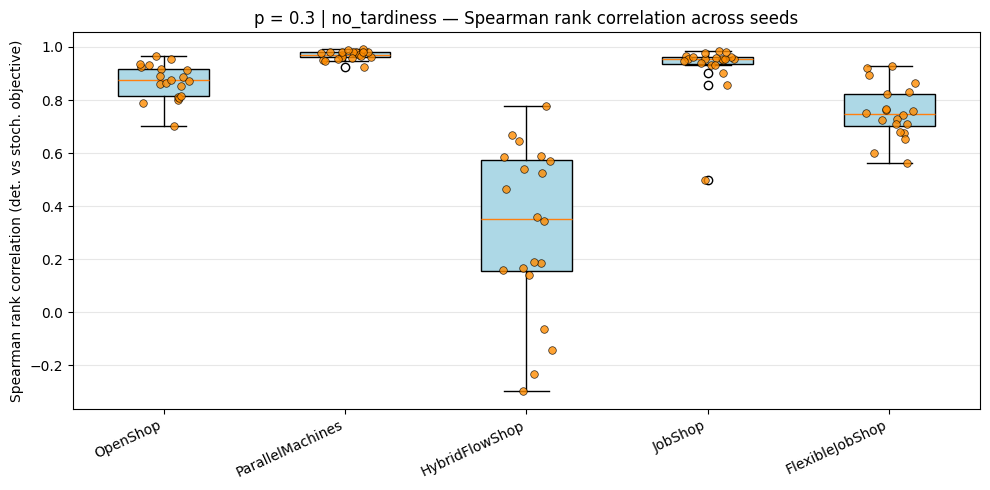

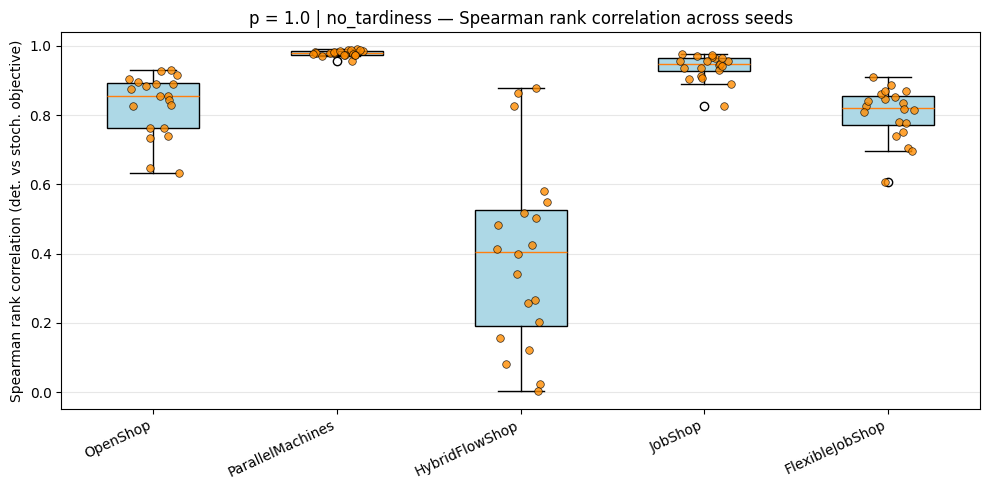

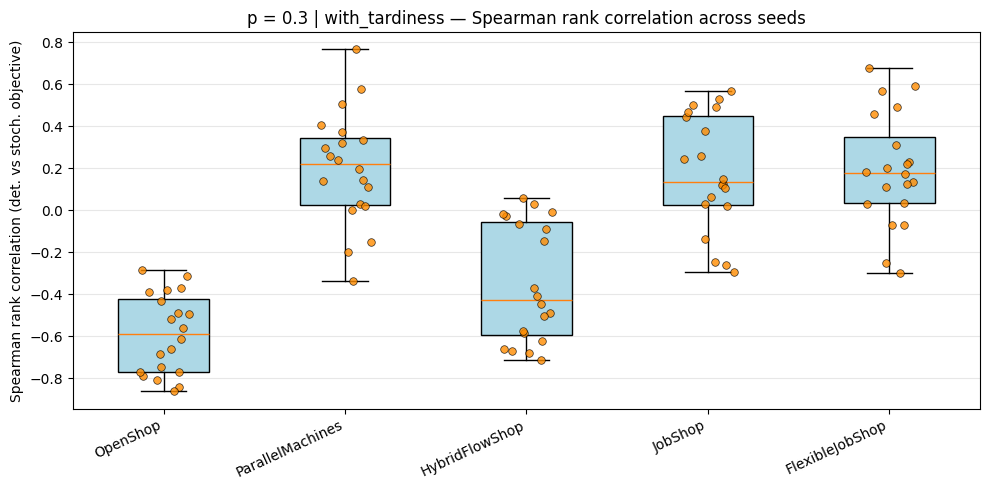

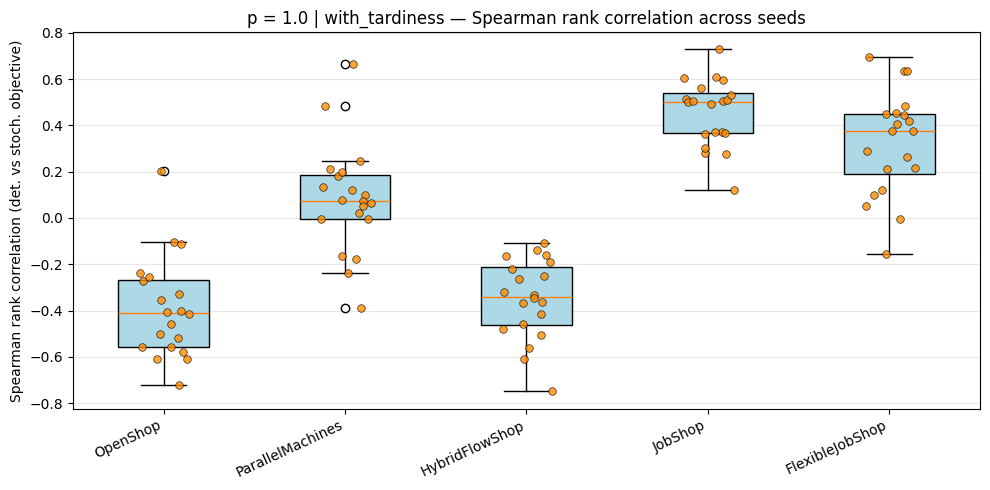

In [4]:
# Build corr_per_seed from the already-computed 'correlation' column
# (no need to recompute Spearman — it was computed during feature engineering)
_df_corr = (
    df_all[["exp_group", "problem_type", "seed", "correlation"]]
    .drop_duplicates()
)
# Map problem_type to base problem name
_df_corr["problem"] = _df_corr["problem_type"].apply(
    lambda p: next((prob for prob in problem_order if str(p).startswith(prob)), str(p))
)

for exp_group in EXP_GROUP_ORDER:
    df_eg = _df_corr[_df_corr["exp_group"] == exp_group]
    fig, ax = plt.subplots(figsize=(10, 5))

    data_for_box = [
        df_eg[df_eg["problem"] == p]["correlation"].values
        for p in problem_order
    ]

    bp = ax.boxplot(data_for_box, tick_labels=problem_order, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")

    # Overlay individual seed points
    for i, vals in enumerate(data_for_box, start=1):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color="darkorange", s=30, zorder=3, alpha=0.8,
                   edgecolors="black", linewidths=0.5)

    ax.set_xticklabels(problem_order, rotation=25, ha="right")
    ax.set_ylabel("Spearman rank correlation (det. vs stoch. objective)")
    ax.set_title(f"{exp_group} — Spearman rank correlation across seeds")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Correlation vs rank

For a selected method (default `det_opt_1`), scatter the per-instance
`correlation` against `rank`.

- x-axis: `correlation` (Spearman rank correlation per problem+seed)
- y-axis: `rank` (1 = best within that problem+seed)

Lower `rank` is better, so a downward trend means the method tends
to rank better as correlation increases.

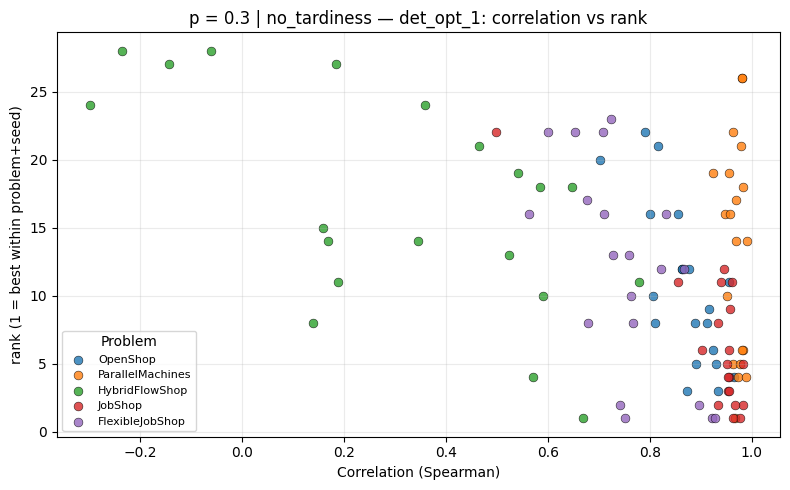

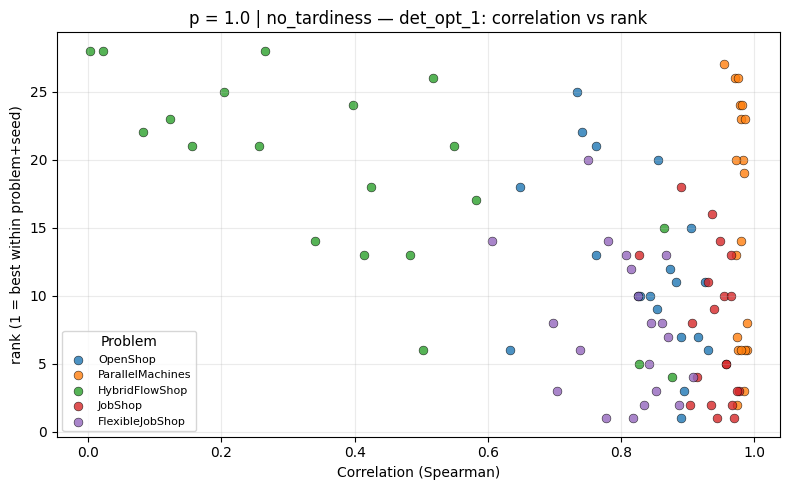

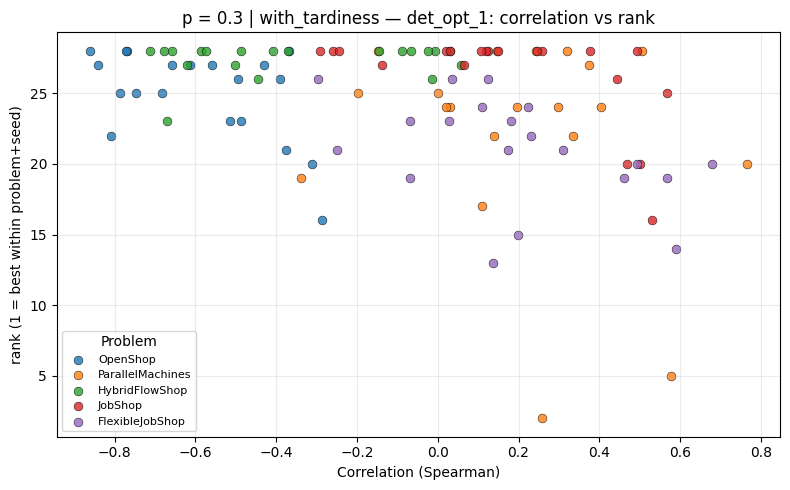

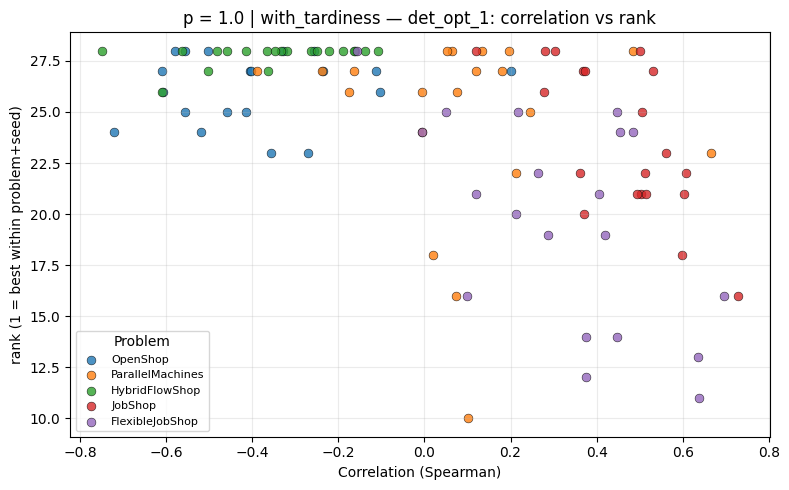

In [5]:
selected_method = "det_opt_1"  # change this to inspect another method
# selected_method = "std_simh_1"  # change this to inspect another method
# selected_method = "dyn_simh_2"  # change this to inspect another method

for exp_group, df in df_all.groupby("exp_group", sort=False, observed=False):
    df = df.copy()
    df_method = df[df["simheuristic"] == selected_method].copy()
    if df_method.empty:
        raise ValueError(
            f"No rows found for simheuristic='{selected_method}' in {exp_group}"
        )

    fig, ax = plt.subplots(figsize=(8, 5))

    for problem_name in problem_order:
        problem_rows = df_method[df_method["problem_type"].str.startswith(problem_name)]
        if not problem_rows.empty:
            ax.scatter(
                problem_rows["correlation"],
                problem_rows["rank"],
                s=40,
                alpha=0.8,
                label=problem_name,
                edgecolors="black",
                linewidths=0.4,
            )

    ax.set_xlabel("Correlation (Spearman)")
    ax.set_ylabel("rank (1 = best within problem+seed)")
    ax.set_title(f"{exp_group} — {selected_method}: correlation vs rank")
    ax.grid(True, alpha=0.25)
    ax.legend(title="Problem", fontsize=8)
    plt.tight_layout()
    plt.show()


## Solution density over time

Parse the callback logs to count how many new unique schedules were found and
when they were found. A higher density of solutions early on suggests that
delaying simulation (so as not to hinder the deterministic optimiser) is more
important.

### Per-problem CDF for `det_opt_1`

For each problem type separately, show the CDF of new-unique-schedule
discovery times across all seeds, using only the `det_opt_1` simheuristic.

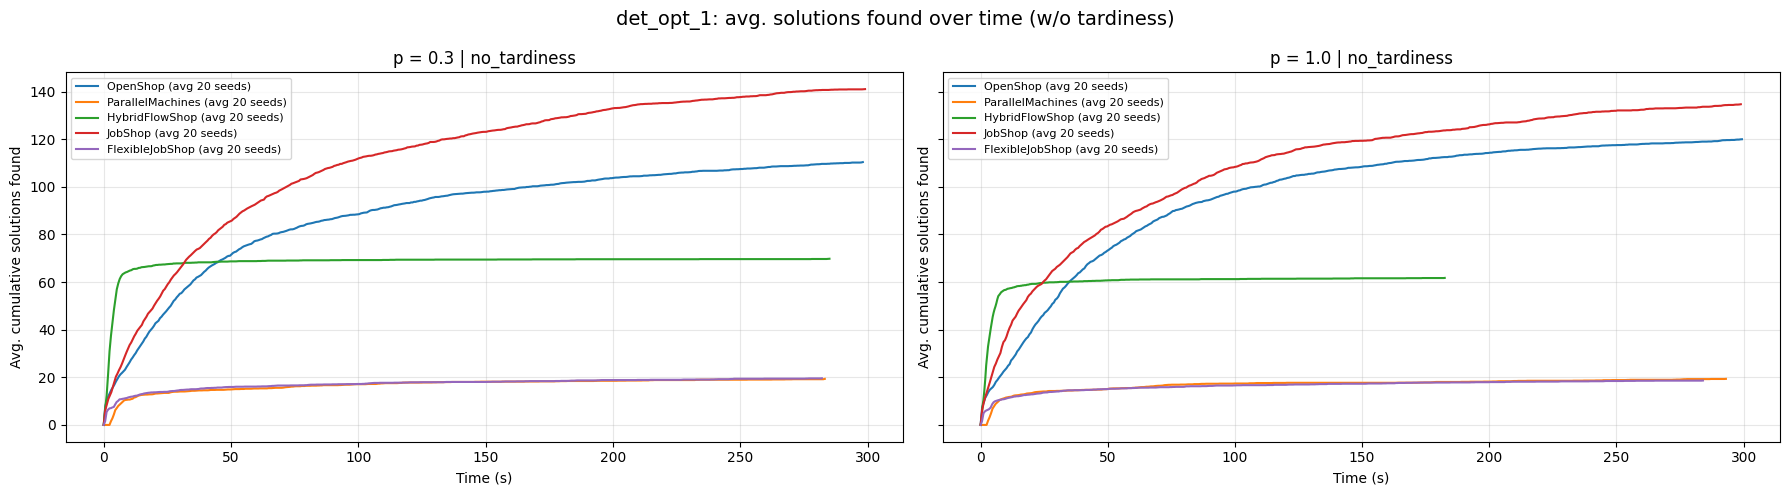

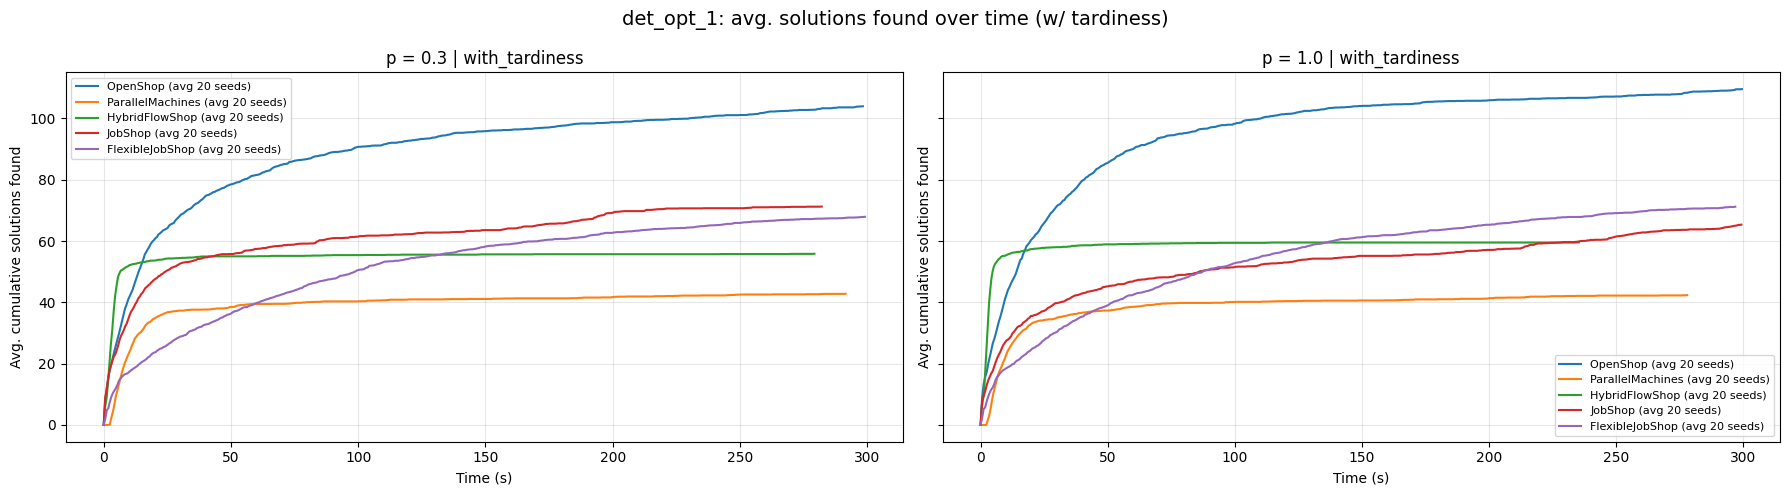

In [6]:
# Toggle: True = cumulative fraction (0–1) pooling all seeds,
#         False = average cumulative count across seeds (shared y-axis).
USE_SCALED_CDF = False

def _plot_cdf_on_ax(ax, exp_group, df_all_local):
    """Plot the avg. cumulative solutions found for all problems on a single axes."""
    df_det = df_all_local[
        (df_all_local["exp_group"] == exp_group)
        & (df_all_local["simheuristic"] == "det_opt_3")
    ]

    for problem_name in problem_order:
        problem_type = problem_type_for_group(problem_name, exp_group)
        df_prob = df_det[df_det["problem_type"] == problem_type]

        seed_times = []
        for _, row in df_prob.iterrows():
            # Use cached callback-log parse results
            key = (row["problem_type"], row["seed"], "det_opt_3")
            times = callback_times_cache.get(key, [])
            seed_times.append(np.sort(times) if times else np.array([]))

        non_empty = [st for st in seed_times if len(st) > 0]
        if not non_empty:
            continue

        n_seeds = len(seed_times)

        if USE_SCALED_CDF:
            all_times = np.sort(np.concatenate(non_empty))
            cdf = np.arange(1, len(all_times) + 1) / len(all_times)
            ax.plot(all_times, cdf, label=problem_name)
        else:
            t_max = max(st[-1] for st in non_empty)
            t_grid = np.linspace(0, t_max, 500)

            cum_matrix = np.zeros((len(non_empty), len(t_grid)))
            for i, st in enumerate(non_empty):
                cum_matrix[i] = np.searchsorted(st, t_grid, side="right")

            avg_cum = cum_matrix.mean(axis=0)
            ax.plot(t_grid, avg_cum, label=f"{problem_name} (avg {n_seeds} seeds)")

    ax.set_xlabel("Time (s)")
    if USE_SCALED_CDF:
        ax.set_ylabel("Cumulative fraction of new unique schedules")
    else:
        ax.set_ylabel("Avg. cumulative solutions found")
    ax.set_title(exp_group)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# --- First pair: first two exp_groups side by side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, eg in zip(axes, EXP_GROUP_ORDER[:2]):
    _plot_cdf_on_ax(ax, eg, df_all)
fig.suptitle("det_opt_1: avg. solutions found over time (w/o tardiness)", fontsize=14)
plt.tight_layout()
plt.show()

# --- Second pair: last two exp_groups side by side ---
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
for ax, eg in zip(axes, EXP_GROUP_ORDER[2:]):
    _plot_cdf_on_ax(ax, eg, df_all)
fig.suptitle("det_opt_1: avg. solutions found over time (w/ tardiness)", fontsize=14)
plt.tight_layout()
plt.show()


## How many unique schedules does the deterministic optimiser find?

For `det_opt_1`, we count the number of unique schedules discovered per seed
for each problem type.  Two views are shown:

1. **Bar chart** — mean count per problem, with individual seed counts overlaid
   as orange dots to reveal variability.
2. **Box plot** — full distribution (median, quartiles, outliers) across seeds,
   making it easy to compare spread between problems.

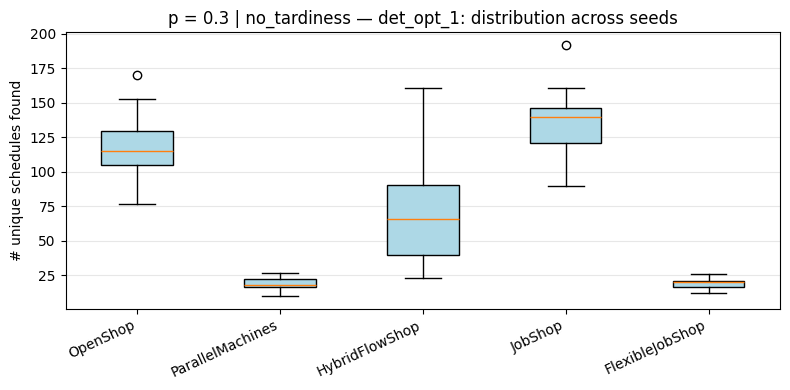

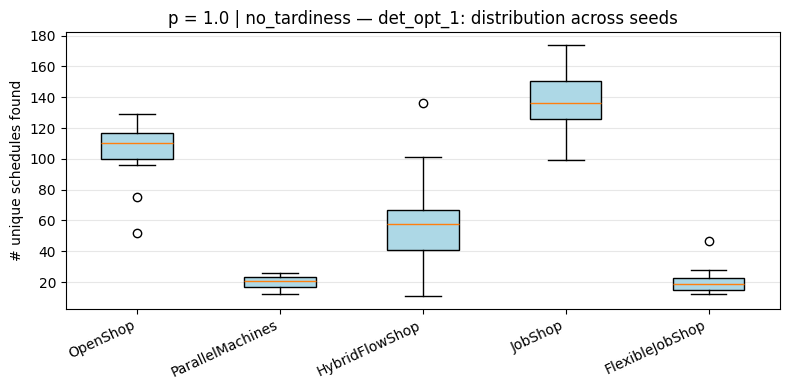

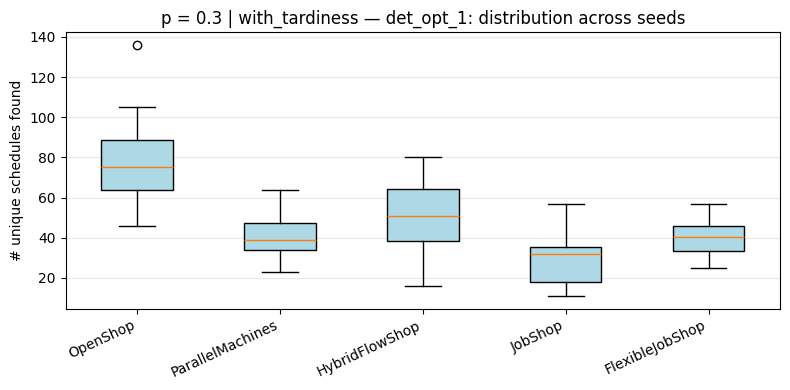

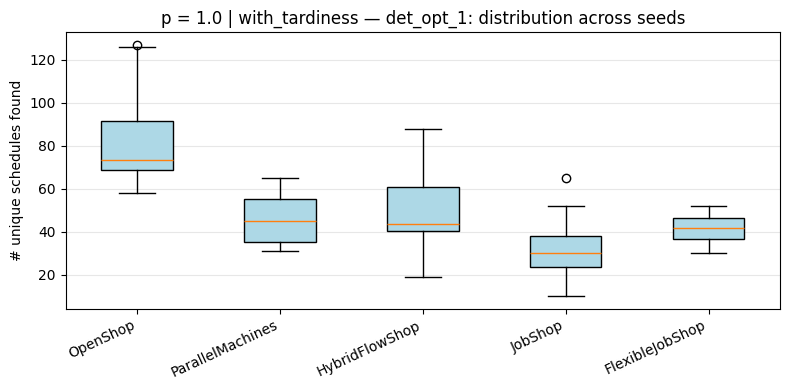

In [7]:
# Use pre-computed num_solutions_found instead of re-parsing callback logs
for exp_group, df in df_all.groupby("exp_group", sort=False, observed=False):
    df = df.copy()
    df_det = df[df["simheuristic"] == "det_opt_1"]

    # One count per (problem, seed) — already stored in num_solutions_found
    counts_per_problem = {}
    for problem_name in problem_order:
        problem_type = problem_type_for_group(problem_name, exp_group)
        df_prob = df_det[df_det["problem_type"] == problem_type]
        counts_per_problem[problem_name] = df_prob["num_solutions_found"].astype(int).tolist()

    fig, ax = plt.subplots(figsize=(8, 4))
    data_for_box = [counts_per_problem[p] if counts_per_problem[p] else [0]
                    for p in problem_order]
    bp = ax.boxplot(data_for_box, tick_labels=problem_order, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")
    ax.set_ylabel("# unique schedules found")
    ax.set_title(f"{exp_group} — det_opt_1: distribution across seeds")
    ax.set_xticklabels(problem_order, rotation=25, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## Percentage best, average gap\_to\_best, and average rank per algorithm group

For each algorithm group we report three summary tables:

1. **Percentage best** — how often the group achieved the best (lowest)
   objective across `(problem_type, seed)` instances.
2. **Average gap\_to\_best** — mean relative gap to the best solution.
3. **Average rank** — mean rank among all algorithms.

Columns show the overall value and breakdowns per experiment group and
per problem type.

In [8]:
# Use the algo_group column computed during feature engineering
_df_metrics = df_all.copy()

def _build_metric_summary(df, metric, groups_list):
    """Mean `metric` per algo_group, overall + per exp_group + per problem."""
    cols = {}

    # Overall
    cols["all"] = df.groupby("algo_group")[metric].mean()

    # Per exp_group
    for eg in EXP_GROUP_ORDER:
        sub = df[df["exp_group"] == eg]
        if not sub.empty:
            cols[eg] = sub.groupby("algo_group")[metric].mean()

    # Per problem type
    for prob in problem_order:
        sub = df[df["problem_type"].str.startswith(prob)]
        if not sub.empty:
            cols[prob] = sub.groupby("algo_group")[metric].mean()

    return pd.DataFrame(cols).reindex(groups_list).round(4)

def _build_pct_best_summary(df_best, groups_list):
    """Percentage of instances each algo_group was the actual best,
    overall + per exp_group + per problem."""
    cols = {}

    # Overall
    n = len(df_best)
    cols["all"] = (df_best["algo_group"].value_counts() / n * 100).round(1)

    # Per exp_group
    for eg in EXP_GROUP_ORDER:
        sub = df_best[df_best["exp_group"] == eg]
        if not sub.empty:
            cols[eg] = (sub["algo_group"].value_counts() / len(sub) * 100).round(1)

    # Per problem type
    for prob in problem_order:
        sub = df_best[df_best["problem_type"].str.startswith(prob)]
        if not sub.empty:
            cols[prob] = (sub["algo_group"].value_counts() / len(sub) * 100).round(1)

    return pd.DataFrame(cols).reindex(groups_list).fillna(0).round(1)

# Best per instance (using 'mean' objective; compute here for EDA)
groups_all = [g for g in GROUP_ORDER if g in df_all["algo_group"].unique()]
df_best_per_instance = (
    df_all.loc[df_all.groupby(["problem_type", "seed"])["mean"].idxmin()]
    .copy()
)

# --- Percentage best ---
summary_pct_best_groups = _build_pct_best_summary(df_best_per_instance, groups_all).T
print(f"{'=' * 80}")
print(f"Percentage best per algorithm group ({len(df_best_per_instance)} instances, higher is better)")
print(f"{'=' * 80}")
display(summary_pct_best_groups)

# --- Average gap_to_best ---
summary_gap_groups = _build_metric_summary(_df_metrics, "gap_to_best", groups_all).T
print(f"\n{'=' * 80}")
print("Average gap_to_best per algorithm group (lower is better)")
print(f"{'=' * 80}")
display(summary_gap_groups)

# --- Average rank ---
summary_rank_groups = _build_metric_summary(_df_metrics, "rank", groups_all).T
print(f"\n{'=' * 80}")
print("Average rank per algorithm group (lower is better)")
print(f"{'=' * 80}")
display(summary_rank_groups)

# ---- LaTeX table: percentage best per algorithm group ----

# Build a display-ready copy of summary_pct_best_groups
_pct_df = summary_pct_best_groups.copy()

# Rename columns & index using central notation
_pct_df.columns = [LATEX_NOTATION.get(c, c) for c in _pct_df.columns]
_pct_df.index   = [LATEX_NOTATION.get(i, i) for i in _pct_df.index]
_pct_df.index.name = "Category"

_pct_numeric = _pct_df.astype(float)

# Format each cell: bold best + left-aligned data bar
_pct_latex_df = _pct_df.copy()
for row_idx in _pct_numeric.index:
    row = _pct_numeric.loc[row_idx]
    row_max = row.max()
    for col in row.index:
        v = row[col]
        _pct_latex_df.at[row_idx, col] = _fmt_bar_cell(
            v, row_max, is_best=(v == row_max), fmt=".1f"
        )

# Build LaTeX string with midrules between sections
_n_groups = len(groups_all)
_col_fmt = "l" + "c" * _n_groups
_col_headers = " & ".join(
    [f"\\textbf{{{c}}}" for c in _pct_latex_df.columns]
)

_rows_latex = []
_all_indices = list(_pct_latex_df.index)
_overall_end = 1                          # 'All' row
_expgroup_end = _overall_end + len(EXP_GROUP_ORDER)

for i, row_idx in enumerate(_all_indices):
    row_vals = " & ".join(str(v) for v in _pct_latex_df.loc[row_idx])
    _rows_latex.append(f"    {_tex_escape(row_idx)} & {row_vals} \\\\")
    if i == _overall_end - 1 or i == _expgroup_end - 1:
        _rows_latex.append("    \\midrule")

_body = "\n".join(_rows_latex)

_latex_pct_best = (
    "% Requires: \\usepackage{xcolor}   (for \\color and named colours)\n"
    "%           \\usepackage{booktabs}  (for \\toprule, \\midrule, \\bottomrule)\n"
    "\\begin{table}[ht!]\n"
    "\\centering\n"
    f"\\begin{{tabular}}{{{_col_fmt}}}\n"
    "    \\toprule\n"
    f"    \\textbf{{Category}} & {_col_headers} \\\\\n"
    "    \\midrule\n"
    f"{_body}\n"
    "    \\bottomrule\n"
    "\\end{tabular}\n"
    "\\caption{Percentage of instances (\\%) each algorithm group achieved the best "
    "(lowest) mean objective, broken down by overall, experiment group, and problem "
    "type.  Best value per row is \\textbf{bold}.  "
    + ("Background bars are scaled proportionally to the row maximum for quick visual comparison.  " if LATEX_SHOW_BARS else "")
    + "Higher is better.}\n"
    "\\label{tab:pct_best_per_algo_group}\n"
    "\\end{table}\n"
)

LATEX_DIR = Path("latex")
LATEX_DIR.mkdir(parents=True, exist_ok=True)
_tex_path = LATEX_DIR / "pct_best_per_algo_group.tex"
with open(_tex_path, "w", encoding="utf-8") as _f:
    _f.write(_latex_pct_best)
print(f"\nSaved LaTeX table to: {_tex_path}")
print(_latex_pct_best)


Percentage best per algorithm group (400 instances, higher is better)


algo_group,det_opt,sim_last,std_simh,dyn_simh
all,16.0,31.2,22.2,30.5
p = 0.3 | no_tardiness,26.0,40.0,14.0,20.0
p = 1.0 | no_tardiness,21.0,43.0,9.0,27.0
p = 0.3 | with_tardiness,8.0,22.0,34.0,36.0
p = 1.0 | with_tardiness,9.0,20.0,32.0,39.0
OpenShop,12.5,32.5,25.0,30.0
ParallelMachines,12.5,16.2,28.7,42.5
HybridFlowShop,6.2,15.0,22.5,56.2
JobShop,16.2,51.2,12.5,20.0
FlexibleJobShop,32.5,41.2,22.5,3.8



Average gap_to_best per algorithm group (lower is better)


algo_group,det_opt,sim_last,std_simh,dyn_simh
all,0.6026,0.4073,0.2061,0.4336
p = 0.3 | no_tardiness,0.0350,0.0351,0.0491,0.0454
p = 1.0 | no_tardiness,0.0335,0.0365,0.0457,0.0453
p = 0.3 | with_tardiness,1.1325,0.7281,0.4256,1.2421
p = 1.0 | with_tardiness,1.2094,0.8294,0.3041,0.4017
OpenShop,0.3461,0.3051,0.0979,0.0671
ParallelMachines,0.6610,0.4976,0.2504,0.2270
HybridFlowShop,1.3501,0.6506,0.1096,0.0565
JobShop,0.1847,0.1596,0.1550,0.1080
FlexibleJobShop,0.4710,0.4236,0.4178,1.7094



Average rank per algorithm group (lower is better)


algo_group,det_opt,sim_last,std_simh,dyn_simh
all,15.1950,14.2488,14.6250,14.2419
p = 0.3 | no_tardiness,11.0975,11.1500,16.8688,17.1775
p = 1.0 | no_tardiness,11.6750,11.8562,16.3612,16.6800
p = 0.3 | with_tardiness,19.2750,16.6525,12.4438,11.9812
p = 1.0 | with_tardiness,18.7325,17.3362,12.8262,11.1288
OpenShop,16.1219,15.1547,14.9016,12.5328
ParallelMachines,16.7469,16.3203,14.4297,11.6234
HybridFlowShop,19.1219,17.2172,13.2000,10.7328
JobShop,12.7250,11.7391,16.5250,16.0984
FlexibleJobShop,11.2594,10.8125,14.0688,20.2219



Saved LaTeX table to: latex\pct_best_per_algo_group.tex
% Requires: \usepackage{xcolor}   (for \color and named colours)
%           \usepackage{booktabs}  (for \toprule, \midrule, \bottomrule)
\begin{table}[ht!]
\centering
\begin{tabular}{lcccc}
    \toprule
    \textbf{Category} & \textbf{Det.~opt.} & \textbf{Sim-last} & \textbf{Std.~simh.} & \textbf{Dyn.~simh.} \\
    \midrule
    All & 16.0 & \textbf{31.2} & 22.2 & 30.5 \\
    \midrule
    w/o tard., $p{=}0.3$ & 26.0 & \textbf{40.0} & 14.0 & 20.0 \\
    w/o tard., $p{=}1.0$ & 21.0 & \textbf{43.0} & 9.0 & 27.0 \\
    w/ tard., $p{=}0.3$ & 8.0 & 22.0 & 34.0 & \textbf{36.0} \\
    w/ tard., $p{=}1.0$ & 9.0 & 20.0 & 32.0 & \textbf{39.0} \\
    \midrule
    OS & 12.5 & \textbf{32.5} & 25.0 & 30.0 \\
    PM & 12.5 & 16.2 & 28.7 & \textbf{42.5} \\
    HFS & 6.2 & 15.0 & 22.5 & \textbf{56.2} \\
    JS & 16.2 & \textbf{51.2} & 12.5 & 20.0 \\
    FJS & 32.5 & \textbf{41.2} & 22.5 & 3.8 \\
    \bottomrule
\end{tabular}
\caption{Percentage of

C:\Users\jbt640\AppData\Local\Temp\ipykernel_14624\668356346.py:95: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _pct_latex_df.at[row_idx, col] = _fmt_bar_cell(
C:\Users\jbt640\AppData\Local\Temp\ipykernel_14624\668356346.py:95: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '\textbf{31.2}' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _pct_latex_df.at[row_idx, col] = _fmt_bar_cell(
C:\Users\jbt640\AppData\Local\Temp\ipykernel_14624\668356346.py:95: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '22.2' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _pct_latex_df

### Problem characteristics: correlation, solutions found, and discovery rate

For each problem type (and overall / per experiment group) we report the
average **correlation** (Spearman rank correlation between DCOP and SCOP
objectives), **num\_solutions\_found** (unique schedules discovered by
`det_opt_1`), and **solution\_discovery\_rate** (normalised AUC of the
solution-discovery CDF; higher means solutions were found earlier).

Since these features are constant across simheuristics within a
`(problem_type, seed)` instance, we first deduplicate to one row per
instance before averaging.

In [9]:
# One row per (problem_type, seed) — features are identical across simheuristics
_df_instance = (
    df_all.groupby(["problem_type", "seed"], sort=False)
    [["correlation", "num_solutions_found", "solution_discovery_rate"]]
    .first()
    .reset_index()
)

# Map problem_type to base problem name
_df_instance["problem"] = _df_instance["problem_type"].apply(
    lambda p: next((prob for prob in problem_order if str(p).startswith(prob)), str(p))
)

# Re-attach exp_group (take the first; each problem_type maps to one exp_group)
_eg_map = df_all.groupby("problem_type")["exp_group"].first()
_df_instance["exp_group"] = _df_instance["problem_type"].map(_eg_map)

_metrics = ["correlation", "num_solutions_found", "solution_discovery_rate"]

def _build_problem_char_table(df, metrics):
    """Average problem characteristics, overall + per exp_group + per problem."""
    rows = {}

    # Overall
    rows["all"] = df[metrics].mean()

    # Per exp_group
    for eg in EXP_GROUP_ORDER:
        sub = df[df["exp_group"] == eg]
        if not sub.empty:
            rows[eg] = sub[metrics].mean()

    # Per problem type
    for prob in problem_order:
        sub = df[df["problem"] == prob]
        if not sub.empty:
            rows[prob] = sub[metrics].mean()

    return pd.DataFrame(rows).T.round(4)

problem_char_table = _build_problem_char_table(_df_instance, _metrics)
problem_char_table.index.name = "category"
print(f"{'=' * 80}")
print("Average problem characteristics per category")
print(f"{'=' * 80}")
display(problem_char_table)


Average problem characteristics per category


,correlation,num_solutions_found,solution_discovery_rate
category,,,
all,0.3766,59.5950,0.8930
p = 0.3 | no_tardiness,0.7653,72.3400,0.8733
p = 1.0 | no_tardiness,0.7892,67.9400,0.8702
p = 0.3 | with_tardiness,-0.0726,47.7100,0.9183
p = 1.0 | with_tardiness,0.0243,50.3900,0.9103
OpenShop,0.1802,96.0875,0.8104
ParallelMachines,0.5580,31.3750,0.9069
HybridFlowShop,0.0013,57.1500,0.9839
JobShop,0.6246,83.2000,0.8649


# Linear regression per simheuristic

For **each** simheuristic we fit an OLS regression. The predictors can be
toggled in the `predictors` list in the code cell below. Significance is indicated with stars:
`***` p < 0.001, `**` p < 0.01, `*` p < 0.05.

A **negative** coefficient means higher values of that feature → better
(lower) rank for that simheuristic relative to others.

In [10]:
fitted_models = {}  # {exp_group: {simheuristic: model}}
predictors = [
    "const",
    "correlation",
    "num_solutions_found",
    # "corr_per_solution",
    # "solution_discovery_rate",
    # "time_last_sol_found",
    ]  # toggle features here
dependent_var = "rank"

for exp_group, df in df_all.groupby("exp_group", sort=False, observed=False):
    df = df.copy()
    simheuristics = sorted(df["simheuristic"].unique())
    rows = []
    fitted_models[exp_group] = {}

    for simh in simheuristics:
        df_simh = df[df["simheuristic"] == simh].copy()

        y = df_simh[dependent_var]
        X = df_simh[[x for x in predictors if x != "const"]]
        X = sm.add_constant(X)

        model = sm.OLS(y, X).fit()
        fitted_models[exp_group][simh] = model

        row = {"simheuristic": simh, "R²_adj": f"{model.rsquared_adj:.3f}"}
        for pred in predictors:
            row[pred] = _fmt_coef(model.params[pred], model.pvalues[pred])
        rows.append(row)

    summary = pd.DataFrame(rows).set_index("simheuristic")
    print(f"{'=' * 60}")
    print(f"Experiment group: {exp_group}")
    print(f"{'=' * 60}")
    print(summary.to_string())
    print()


Experiment group: p = 0.3 | no_tardiness
              R²_adj       const  correlation num_solutions_found
simheuristic                                                     
det_opt_1      0.297  24.1892***  -13.2113***            -0.0315*
det_opt_2      0.205  19.4049***  -10.1742***            -0.0301*
det_opt_3      0.047  12.8645***      -0.5182            -0.0336*
det_opt_4      0.093  16.2898***      -0.1305          -0.0426***
dyn_simh_1     0.212  13.7038***      -0.8960           0.0758***
dyn_simh_2     0.313  10.7682***       0.1253           0.0941***
dyn_simh_3    -0.014  15.1288***      -0.5999              0.0124
dyn_simh_4     0.010  13.3943***       2.7325              0.0146
dyn_simh_5     0.090  11.9036***       3.3545            0.0416**
dyn_simh_6     0.079  12.3691***       4.3602            0.0375**
dyn_simh_7     0.019  16.6283***       3.0439             -0.0229
dyn_simh_8    -0.001  12.9502***       3.0379              0.0092
sim_last_1     0.249  22.8756***  -

## Decision boundary: which algorithm group is predicted best?

For each point on a grid of `(correlation, num_solutions_found)` we use the
**individual** OLS models (fitted earlier per simheuristic) to predict
`rank`.  The grid cell is coloured by the **algorithm group** of the
individual simheuristic with the lowest predicted rank.

Scatter points show the **actual** data: one point per `(problem_type, seed)`,
coloured by the algorithm group of the simheuristic that *actually* achieved the best
rank.

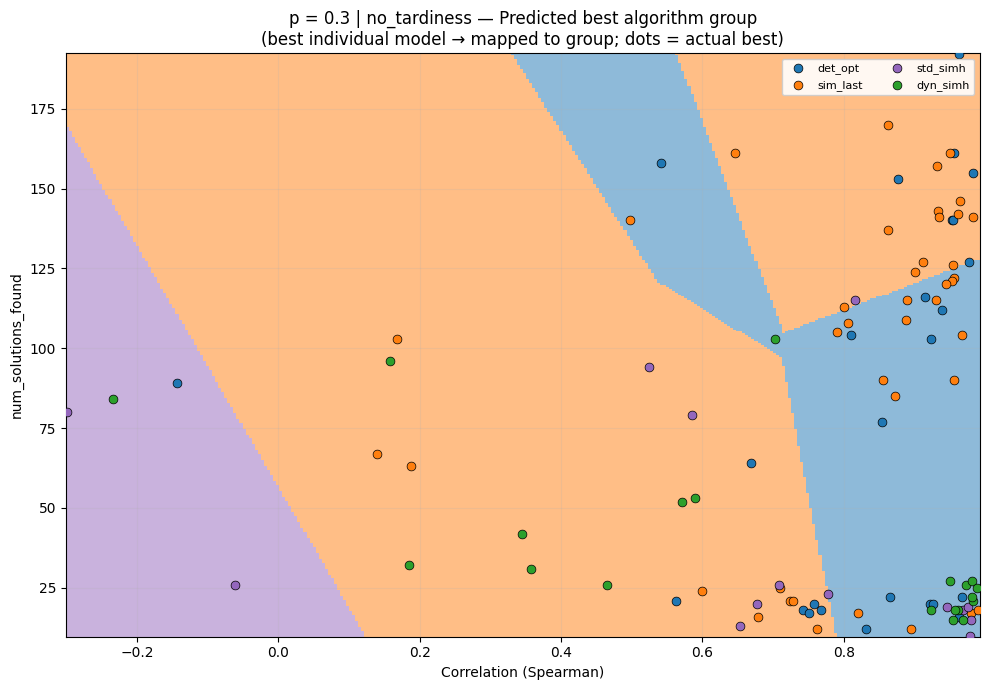

p = 0.3 | no_tardiness — Actual best group (100 instances)
          count  percentage
group                      
det_opt      26        26.0
sim_last     40        40.0
std_simh     14        14.0
dyn_simh     20        20.0



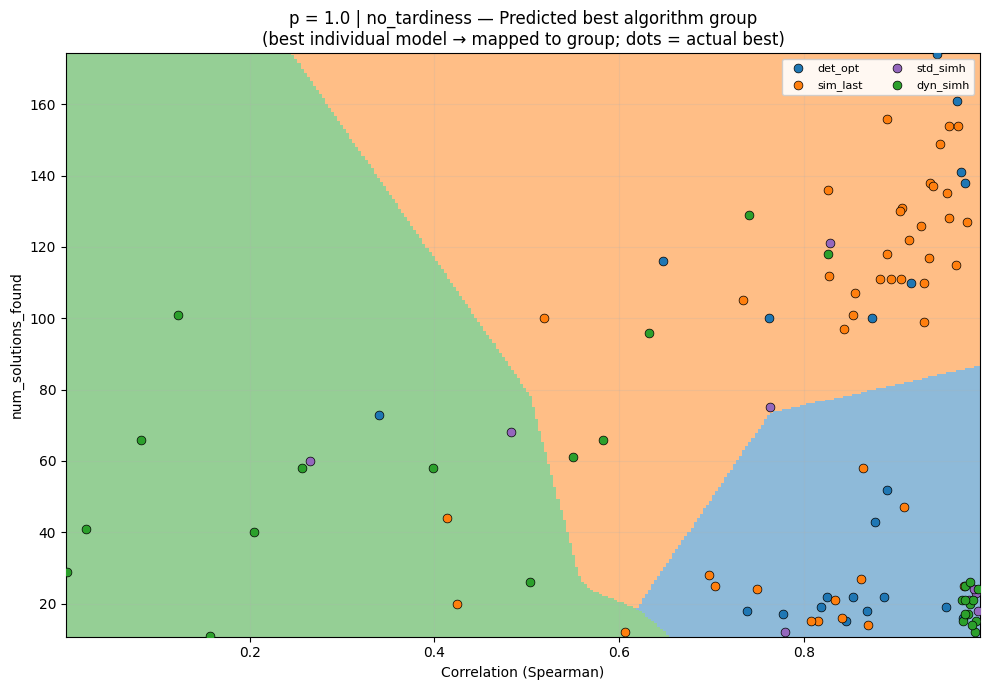

p = 1.0 | no_tardiness — Actual best group (100 instances)
          count  percentage
group                      
det_opt      21        21.0
sim_last     43        43.0
std_simh      9         9.0
dyn_simh     27        27.0



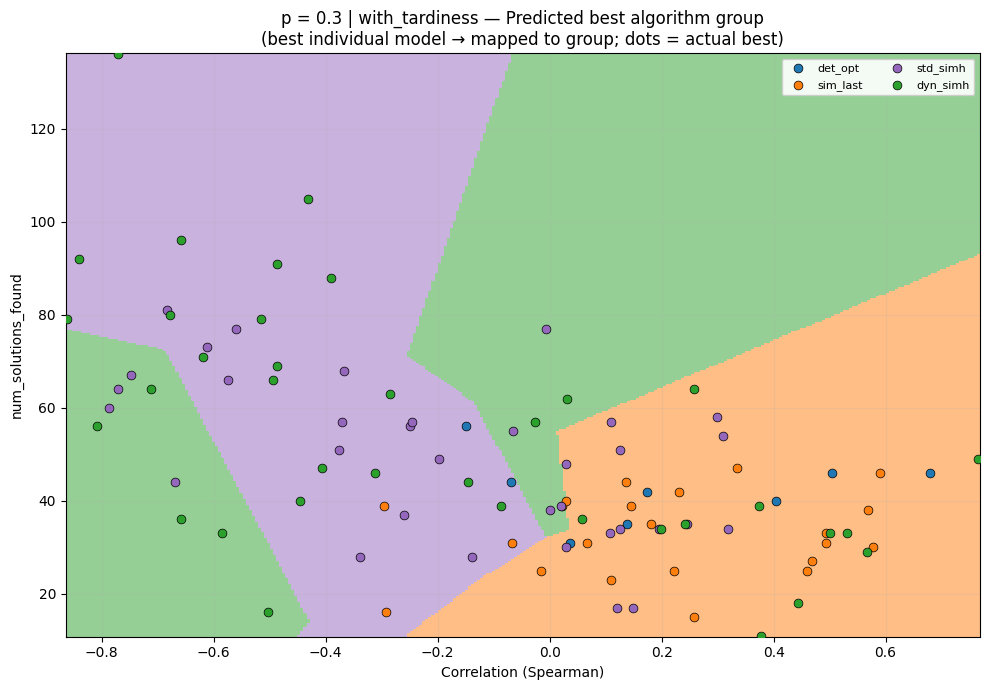

p = 0.3 | with_tardiness — Actual best group (100 instances)
          count  percentage
group                      
det_opt       8         8.0
sim_last     22        22.0
std_simh     34        34.0
dyn_simh     36        36.0



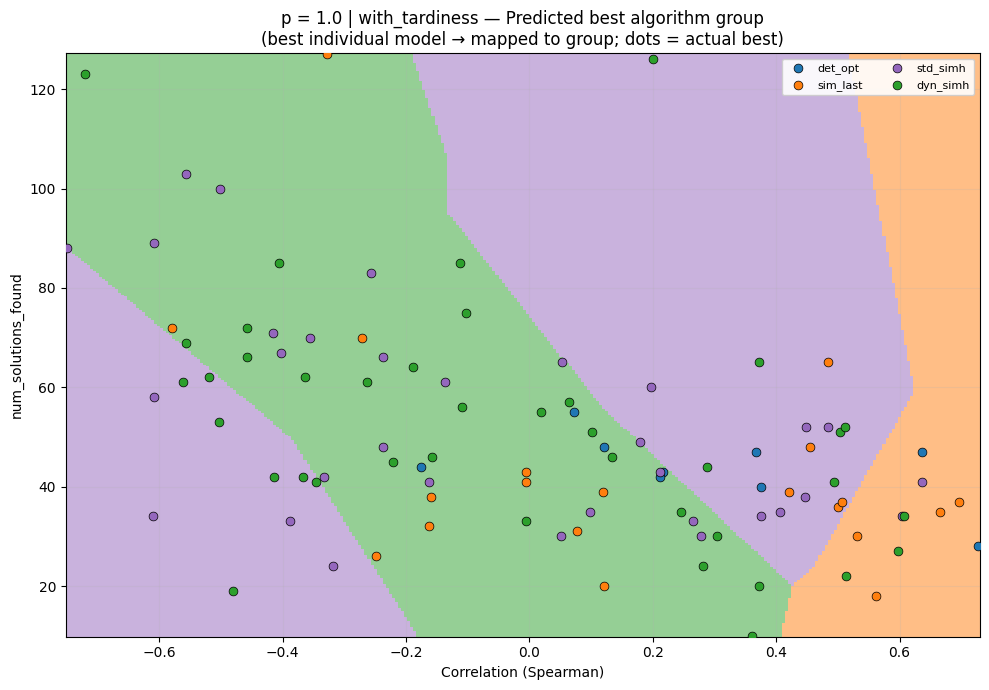

p = 1.0 | with_tardiness — Actual best group (100 instances)
          count  percentage
group                      
det_opt       9         9.0
sim_last     20        20.0
std_simh     32        32.0
dyn_simh     39        39.0



In [11]:
for exp_group, models in fitted_models.items():
    df_exp = df_all[df_all["exp_group"] == exp_group].copy()
    all_simh = sorted(models.keys())
    groups = [g for g in GROUP_ORDER if g in {_algo_group(s) for s in all_simh}]

    # --- Build prediction grid ---
    corr_min = df_exp["correlation"].min()
    corr_max = df_exp["correlation"].max()
    nsf_min = df_exp["num_solutions_found"].min()
    nsf_max = df_exp["num_solutions_found"].max()

    n_grid = 300
    corr_vals = np.linspace(corr_min, corr_max, n_grid)
    nsf_vals = np.linspace(nsf_min, nsf_max, n_grid)
    corr_grid, nsf_grid = np.meshgrid(corr_vals, nsf_vals)

    X_grid = pd.DataFrame({
        "correlation": corr_grid.ravel(),
        "num_solutions_found": nsf_grid.ravel(),
    })
    X_grid["corr_per_solution"] = (
        X_grid["correlation"] / X_grid["num_solutions_found"]
    )

    # Keep only the features the models were fitted with
    sample_model = next(iter(models.values()))
    feature_names = [p for p in sample_model.params.index if p != "const"]
    X_grid = sm.add_constant(X_grid[feature_names])

    # Predict with every individual model, find the best, map to group
    predictions = np.column_stack([
        models[simh].predict(X_grid) for simh in all_simh
    ])
    best_simh_idx = predictions.argmin(axis=1)
    best_group_per_cell = np.array([
        groups.index(_algo_group(all_simh[i])) for i in best_simh_idx
    ]).reshape(corr_grid.shape)

    # --- Actual best simheuristic per (problem_type, seed) ---
    df_best_per_instance = (
        df_exp.loc[df_exp.groupby(["problem_type", "seed"])[dependent_var].idxmin()]
        .copy()
    )

    # --- Plot ---
    cmap = ListedColormap([GROUP_COLORS[g] for g in groups])
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.pcolormesh(corr_grid, nsf_grid, best_group_per_cell,
                  cmap=cmap, alpha=0.5, shading="auto",
                  vmin=0, vmax=len(groups) - 1)

    for i, grp in enumerate(groups):
        subset = df_best_per_instance[df_best_per_instance["algo_group"] == grp]
        ax.scatter(subset["correlation"], subset["num_solutions_found"],
                   color=GROUP_COLORS[grp], edgecolors="black", linewidths=0.5,
                   s=40, zorder=3, label=grp)

    ax.set_xlabel("Correlation (Spearman)")
    ax.set_ylabel("num_solutions_found")
    ax.set_title(f"{exp_group} — Predicted best algorithm group\n"
                 f"(best individual model → mapped to group; dots = actual best)")
    ax.legend(fontsize=8, loc="best", ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # --- Summary table: how often each group was actually best ---
    n_total = len(df_best_per_instance)
    counts = df_best_per_instance["algo_group"].value_counts()
    summary = pd.DataFrame({
        "count": counts,
        "percentage": (counts / n_total * 100).round(1),
    })
    summary.index.name = "group"
    summary = summary.reindex(groups).fillna(0)
    summary["count"] = summary["count"].astype(int)

    print(f"{'=' * 45}")
    print(f"{exp_group} — Actual best group ({n_total} instances)")
    print(f"{'=' * 45}")
    print(summary.to_string())
    print()


## Decision boundary: individual algorithms (ungrouped)

Same approach as above but now for **each individual algorithm** (e.g.
`det_opt_1`, `det_opt_2`, …).  Algorithms from the same group share a
colour palette (light → dark):

- **Blues** — `det_opt`
- **Greens** — `dyn_simh`
- **Oranges / Reds** — `sim_last`
- **Purples** — `std_simh`

The scatter dots show, per `(problem_type, seed)`, which individual
simheuristic *actually* achieved the best rank.  A summary count table is
printed below each plot.

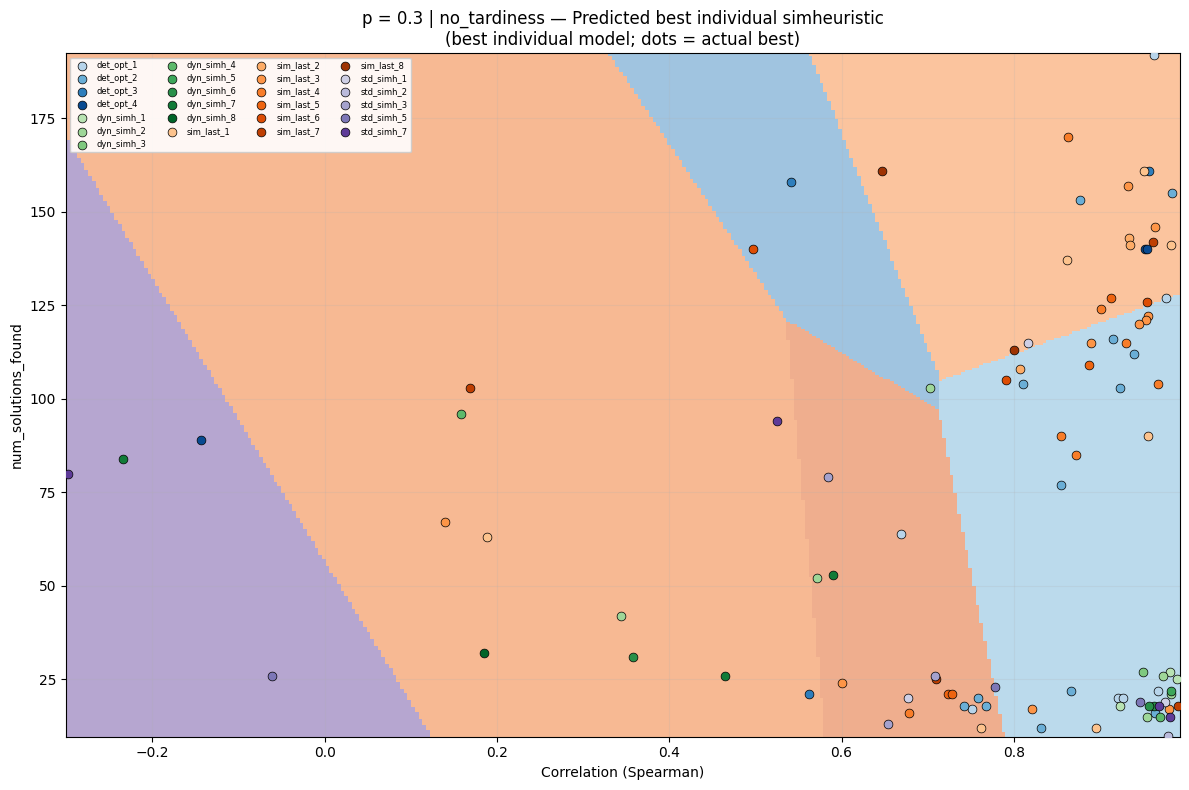

p = 0.3 | no_tardiness — Actual best simheuristic (100 instances)
              count  percentage
simheuristic                   
det_opt_1         7         7.0
det_opt_2        13        13.0
det_opt_3         3         3.0
det_opt_4         3         3.0
dyn_simh_1        3         3.0
dyn_simh_2        6         6.0
dyn_simh_3        1         1.0
dyn_simh_4        2         2.0
dyn_simh_5        1         1.0
dyn_simh_6        3         3.0
dyn_simh_7        3         3.0
dyn_simh_8        1         1.0
sim_last_1        7         7.0
sim_last_2        3         3.0
sim_last_3       10        10.0
sim_last_4        7         7.0
sim_last_5        4         4.0
sim_last_6        3         3.0
sim_last_7        4         4.0
sim_last_8        2         2.0
std_simh_1        3         3.0
std_simh_2        1         1.0
std_simh_3        3         3.0
std_simh_4        0         0.0
std_simh_5        3         3.0
std_simh_6        0         0.0
std_simh_7        4         4.0
std_si

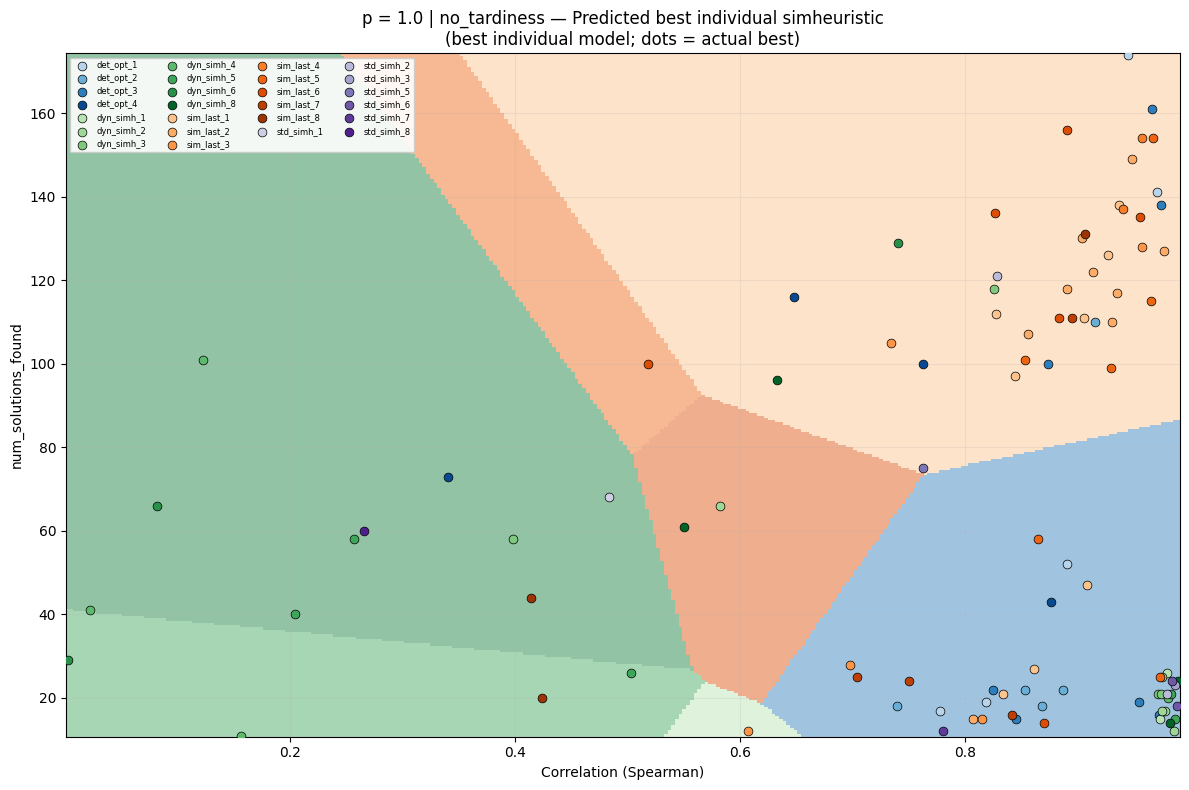

p = 1.0 | no_tardiness — Actual best simheuristic (100 instances)
              count  percentage
simheuristic                   
det_opt_1         5         5.0
det_opt_2         5         5.0
det_opt_3         7         7.0
det_opt_4         4         4.0
dyn_simh_1        2         2.0
dyn_simh_2        5         5.0
dyn_simh_3        4         4.0
dyn_simh_4        4         4.0
dyn_simh_5        5         5.0
dyn_simh_6        3         3.0
dyn_simh_7        0         0.0
dyn_simh_8        4         4.0
sim_last_1        8         8.0
sim_last_2        9         9.0
sim_last_3        5         5.0
sim_last_4        2         2.0
sim_last_5        6         6.0
sim_last_6        6         6.0
sim_last_7        4         4.0
sim_last_8        3         3.0
std_simh_1        1         1.0
std_simh_2        2         2.0
std_simh_3        1         1.0
std_simh_4        0         0.0
std_simh_5        1         1.0
std_simh_6        2         2.0
std_simh_7        1         1.0
std_si

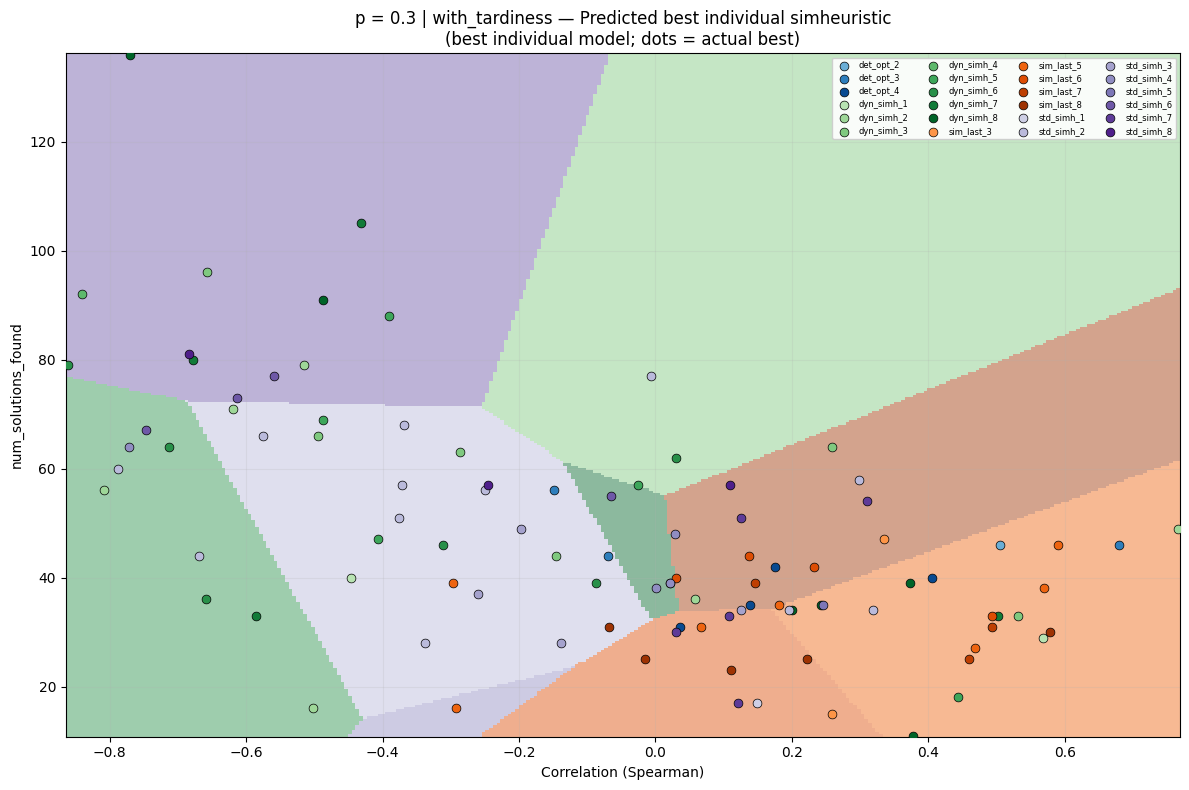

p = 0.3 | with_tardiness — Actual best simheuristic (100 instances)
              count  percentage
simheuristic                   
det_opt_1         0         0.0
det_opt_2         1         1.0
det_opt_3         3         3.0
det_opt_4         4         4.0
dyn_simh_1        2         2.0
dyn_simh_2        6         6.0
dyn_simh_3        6         6.0
dyn_simh_4        1         1.0
dyn_simh_5        5         5.0
dyn_simh_6        6         6.0
dyn_simh_7        4         4.0
dyn_simh_8        6         6.0
sim_last_1        0         0.0
sim_last_2        0         0.0
sim_last_3        2         2.0
sim_last_4        0         0.0
sim_last_5        7         7.0
sim_last_6        5         5.0
sim_last_7        3         3.0
sim_last_8        5         5.0
std_simh_1        1         1.0
std_simh_2       12        12.0
std_simh_3        4         4.0
std_simh_4        4         4.0
std_simh_5        1         1.0
std_simh_6        4         4.0
std_simh_7        5         5.0
std_

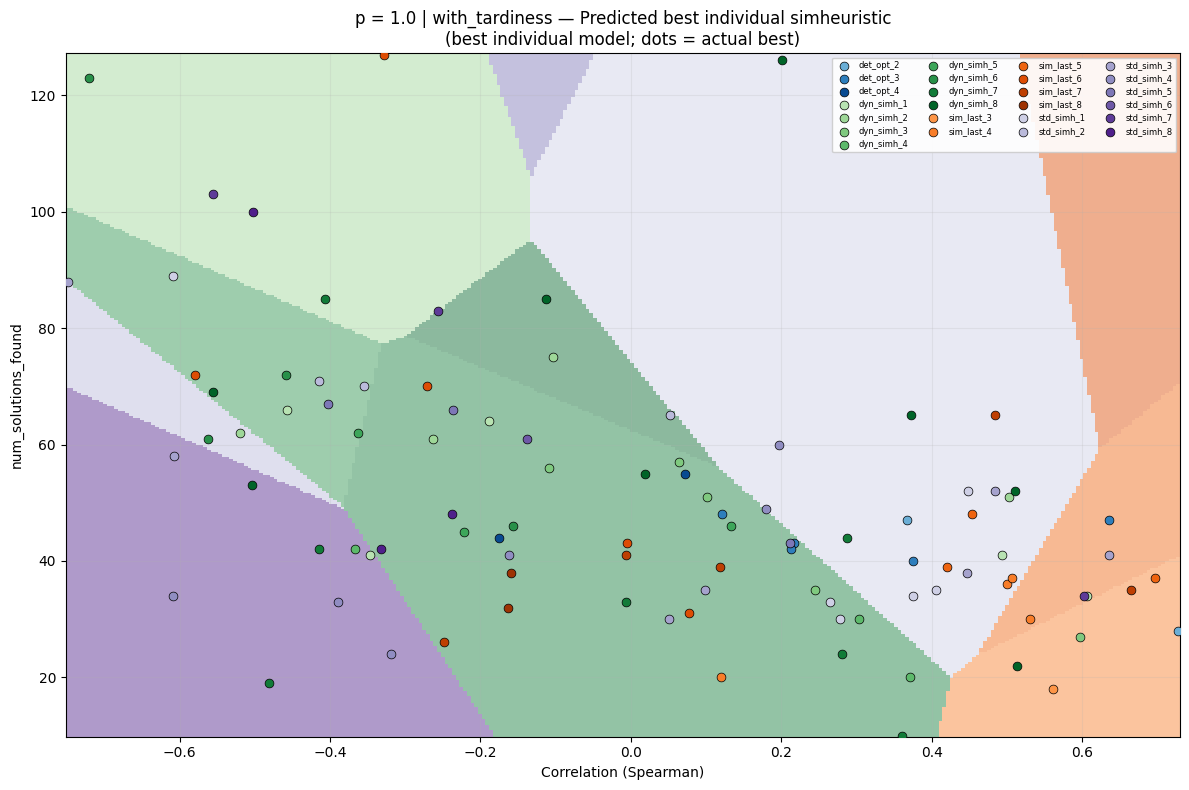

p = 1.0 | with_tardiness — Actual best simheuristic (100 instances)
              count  percentage
simheuristic                   
det_opt_1         0         0.0
det_opt_2         2         2.0
det_opt_3         5         5.0
det_opt_4         2         2.0
dyn_simh_1        5         5.0
dyn_simh_2        4         4.0
dyn_simh_3        5         5.0
dyn_simh_4        3         3.0
dyn_simh_5        3         3.0
dyn_simh_6        4         4.0
dyn_simh_7        7         7.0
dyn_simh_8        8         8.0
sim_last_1        0         0.0
sim_last_2        0         0.0
sim_last_3        1         1.0
sim_last_4        4         4.0
sim_last_5        3         3.0
sim_last_6        5         5.0
sim_last_7        5         5.0
sim_last_8        2         2.0
std_simh_1        6         6.0
std_simh_2        3         3.0
std_simh_3        7         7.0
std_simh_4        6         6.0
std_simh_5        3         3.0
std_simh_6        1         1.0
std_simh_7        3         3.0
std_

In [12]:
for exp_group, models in fitted_models.items():
    df_exp = df_all[df_all["exp_group"] == exp_group].copy()
    all_simh = sorted(models.keys())
    color_map = _build_algo_colormap(all_simh)

    # --- Build prediction grid ---
    corr_min = df_exp["correlation"].min()
    corr_max = df_exp["correlation"].max()
    nsf_min = df_exp["num_solutions_found"].min()
    nsf_max = df_exp["num_solutions_found"].max()

    n_grid = 300
    corr_vals = np.linspace(corr_min, corr_max, n_grid)
    nsf_vals = np.linspace(nsf_min, nsf_max, n_grid)
    corr_grid, nsf_grid = np.meshgrid(corr_vals, nsf_vals)

    X_grid = pd.DataFrame({
        "correlation": corr_grid.ravel(),
        "num_solutions_found": nsf_grid.ravel(),
    })
    X_grid["corr_per_solution"] = (
        X_grid["correlation"] / X_grid["num_solutions_found"]
    )

    # Keep only the features the models were fitted with
    sample_model = next(iter(models.values()))
    feature_names = [p for p in sample_model.params.index if p != "const"]
    X_grid = sm.add_constant(X_grid[feature_names])

    # Predict with every individual model, find the best
    predictions = np.column_stack([
        models[simh].predict(X_grid) for simh in all_simh
    ])
    best_simh_idx = predictions.argmin(axis=1).reshape(corr_grid.shape)

    # --- Actual best simheuristic per (problem_type, seed) ---
    df_best_per_instance = (
        df_exp.loc[df_exp.groupby(["problem_type", "seed"])[dependent_var].idxmin()]
        .copy()
    )

    # --- Plot ---
    cmap = ListedColormap([color_map[s] for s in all_simh])
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.pcolormesh(corr_grid, nsf_grid, best_simh_idx,
                  cmap=cmap, alpha=0.45, shading="auto",
                  vmin=0, vmax=len(all_simh) - 1)

    for simh in all_simh:
        subset = df_best_per_instance[df_best_per_instance["simheuristic"] == simh]
        if subset.empty:
            continue
        ax.scatter(subset["correlation"], subset["num_solutions_found"],
                   color=color_map[simh], edgecolors="black", linewidths=0.5,
                   s=40, zorder=3, label=simh)

    ax.set_xlabel("Correlation (Spearman)")
    ax.set_ylabel("num_solutions_found")
    ax.set_title(f"{exp_group} — Predicted best individual simheuristic\n"
                 f"(best individual model; dots = actual best)")
    ax.legend(fontsize=6, loc="best", ncol=4, framealpha=0.9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    # --- Summary table: how often each simheuristic was actually best ---
    n_total = len(df_best_per_instance)
    counts = df_best_per_instance["simheuristic"].value_counts()
    summary = pd.DataFrame({
        "count": counts,
        "percentage": (counts / n_total * 100).round(1),
    })
    summary.index.name = "simheuristic"
    summary = summary.reindex(all_simh).fillna(0)
    summary["count"] = summary["count"].astype(int)

    print(f"{'=' * 55}")
    print(f"{exp_group} — Actual best simheuristic ({n_total} instances)")
    print(f"{'=' * 55}")
    print(summary.to_string())
    print()


# Linear regression per simheuristic for all problems

This section repeats the same experiments as above, but now using **all rows**
in `df_all` together (all `problem_type` and `exp_group` values pooled).

## Linear regression per simheuristic

For each simheuristic, we fit one pooled OLS model using the same
`predictors` and `dependent_var` as in the per-`exp_group` analysis.


In [13]:
fitted_models_all = {}  # {simheuristic: model} pooled over all problems/groups
rows_all = []

for simh in sorted(df_all["simheuristic"].unique()):
    df_simh = df_all[df_all["simheuristic"] == simh].copy()

    y = df_simh[dependent_var]
    X = df_simh[[x for x in predictors if x != "const"]]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    fitted_models_all[simh] = model

    row = {"simheuristic": simh, "R²_adj": f"{model.rsquared_adj:.3f}"}
    for pred in predictors:
        row[pred] = _fmt_coef(model.params[pred], model.pvalues[pred])
    rows_all.append(row)

summary_all = pd.DataFrame(rows_all).set_index("simheuristic")
print("=" * 60)
print("Pooled regression across all exp_groups and problem_types")
print("=" * 60)
print(summary_all.to_string())


Pooled regression across all exp_groups and problem_types
              R²_adj       const  correlation num_solutions_found
simheuristic                                                     
det_opt_1      0.559  25.0995***  -11.8213***          -0.0417***
det_opt_2      0.457  21.2601***  -11.4202***            -0.0168*
det_opt_3      0.228  16.1113***   -7.1357***             -0.0093
det_opt_4      0.051  16.3704***    -2.2233**           -0.0292**
dyn_simh_1     0.199   9.8730***    5.6123***           0.0532***
dyn_simh_2     0.206   9.4752***    6.0817***           0.0549***
dyn_simh_3     0.081  11.0421***    4.2064***              0.0119
dyn_simh_4     0.129  12.4829***    5.1224***             -0.0007
dyn_simh_5     0.222  10.1356***    6.8543***           0.0355***
dyn_simh_6     0.296   9.9970***    8.1882***           0.0341***
dyn_simh_7     0.166  11.1816***    5.9838***             -0.0024
dyn_simh_8     0.139  10.5984***    5.1452***              0.0046
sim_last_1     0.5

## Residual diagnostics for the pooled OLS models

To assess whether OLS assumptions hold for the pooled regressions we
inspect the residuals of each simheuristic model:

| Assumption | Diagnostic |
|---|---|
| **Normality** | Shapiro-Wilk test, Q-Q plot |
| **Homoscedasticity** | Breusch-Pagan test, residuals-vs-fitted plot |
| **No autocorrelation** | Durbin-Watson statistic |

A summary table is printed first, followed by a visual panel for every
simheuristic.

Residual diagnostics for pooled OLS models


,Shapiro-Wilk stat,Shapiro-Wilk p,Breusch-Pagan stat,Breusch-Pagan p,Durbin-Watson
simheuristic,,,,,
det_opt_1,0.9941,0.1207,50.0189,0.0000,1.6900
det_opt_2,0.9972,0.7270,53.3063,0.0000,1.4898
det_opt_3,0.9905,0.0108,23.4678,0.0000,1.5463
det_opt_4,0.9778,0.0000,16.0666,0.0003,1.5857
dyn_simh_1,0.9859,0.0006,27.0426,0.0000,1.3755
dyn_simh_2,0.9856,0.0005,25.0812,0.0000,1.2634
dyn_simh_3,0.9724,0.0000,54.4137,0.0000,1.5491
dyn_simh_4,0.9870,0.0012,22.1270,0.0000,1.8291
dyn_simh_5,0.9883,0.0026,43.3952,0.0000,1.3681


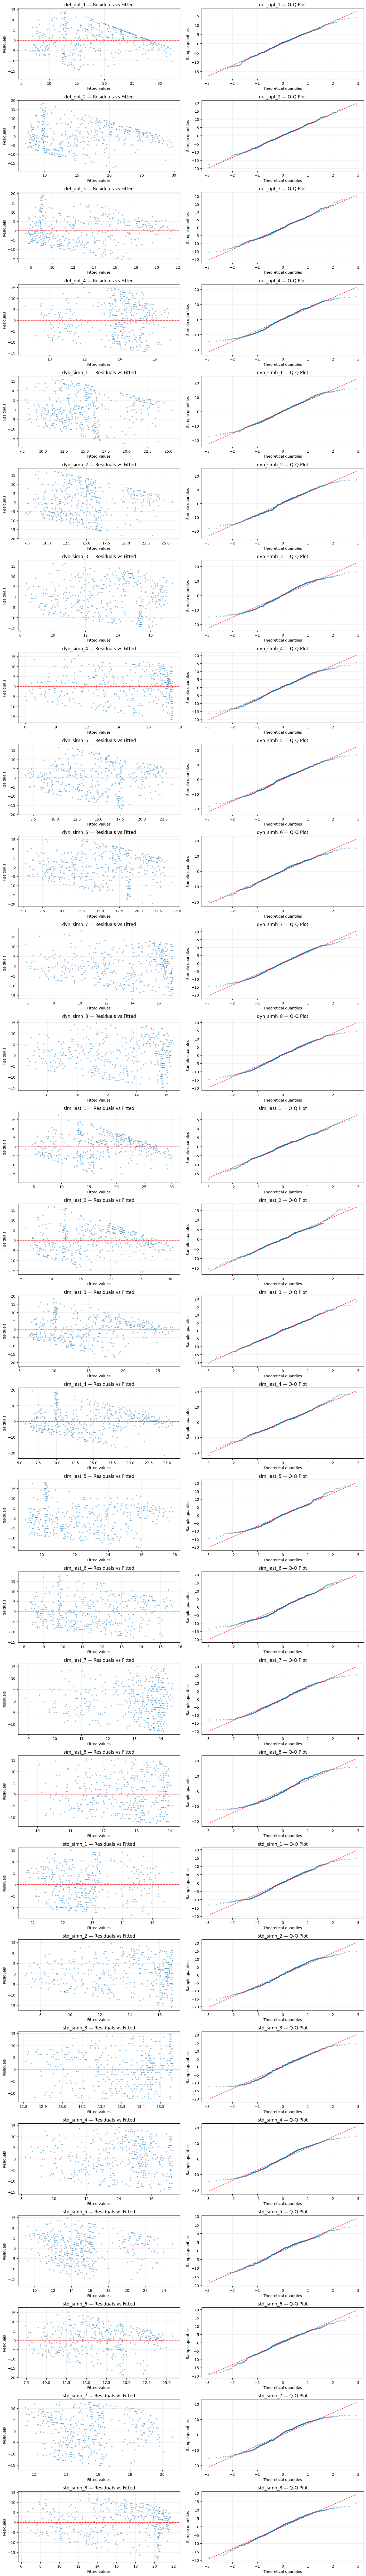

In [14]:
# ---- Summary table of residual tests ------------------------------------
diag_rows = []
for simh in sorted(fitted_models_all.keys()):
    model = fitted_models_all[simh]
    resid = model.resid
    fitted = model.fittedvalues

    # Shapiro-Wilk (normality) — use at most 5000 observations
    if len(resid) > 5000:
        sw_stat, sw_p = shapiro(resid[:5000])
    else:
        sw_stat, sw_p = shapiro(resid)

    # Breusch-Pagan (homoscedasticity)
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, model.model.exog)

    # Durbin-Watson (autocorrelation)
    dw = durbin_watson(resid)

    diag_rows.append({
        "simheuristic": simh,
        "Shapiro-Wilk stat": round(sw_stat, 4),
        "Shapiro-Wilk p": round(sw_p, 4),
        "Breusch-Pagan stat": round(bp_stat, 4),
        "Breusch-Pagan p": round(bp_p, 4),
        "Durbin-Watson": round(dw, 4),
    })

diag_df = pd.DataFrame(diag_rows).set_index("simheuristic")
print("=" * 80)
print("Residual diagnostics for pooled OLS models")
print("=" * 80)
display(diag_df)

# ---- Visual diagnostics per simheuristic ---------------------------------
n_models = len(fitted_models_all)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 3.5 * n_models))

for idx, simh in enumerate(sorted(fitted_models_all.keys())):
    model = fitted_models_all[simh]
    resid = model.resid
    fitted = model.fittedvalues

    # Residuals vs fitted values (homoscedasticity check)
    ax_rf = axes[idx, 0]
    ax_rf.scatter(fitted, resid, s=12, alpha=0.5, edgecolors="none")
    ax_rf.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax_rf.set_xlabel("Fitted values")
    ax_rf.set_ylabel("Residuals")
    ax_rf.set_title(f"{simh} — Residuals vs Fitted")
    ax_rf.grid(True, alpha=0.2)

    # Q-Q plot (normality check)
    ax_qq = axes[idx, 1]
    (osm, osr), (slope, intercept, _) = st_stats.probplot(resid, dist="norm")
    ax_qq.scatter(osm, osr, s=12, alpha=0.5, edgecolors="none")
    ax_qq.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=0.8)
    ax_qq.set_xlabel("Theoretical quantiles")
    ax_qq.set_ylabel("Sample quantiles")
    ax_qq.set_title(f"{simh} — Q-Q Plot")
    ax_qq.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


## Decision boundary: which algorithm group is predicted best?

Same experiment as above, but using `fitted_models_all` and all pooled
instances at once.


Saved: latex\figures\decision_boundary_groups_pooled.pdf
Saved: latex\figures\decision_boundary_groups_pooled.png


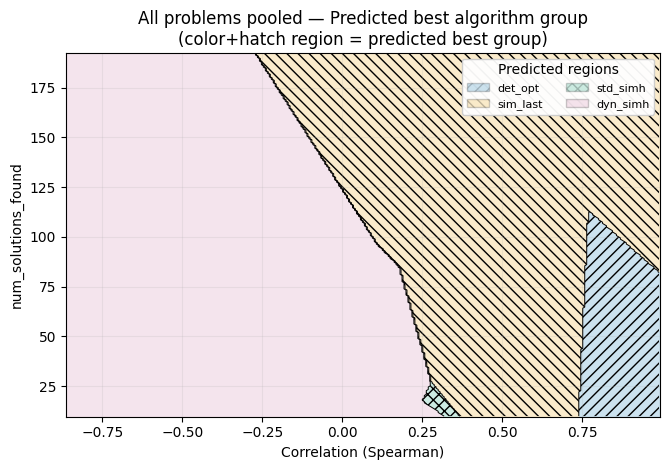

In [15]:
import matplotlib.patches as mpatches
from pathlib import Path

# -----------------------------
# Data + prediction grid
# -----------------------------
df_exp_all = df_all.copy()
all_simh_all = sorted(fitted_models_all.keys())
groups_all = [g for g in GROUP_ORDER if g in {_algo_group(s) for s in all_simh_all}]

corr_min = df_exp_all["correlation"].min()
corr_max = df_exp_all["correlation"].max()
nsf_min = df_exp_all["num_solutions_found"].min()
nsf_max = df_exp_all["num_solutions_found"].max()

n_grid = 300
corr_vals = np.linspace(corr_min, corr_max, n_grid)
nsf_vals = np.linspace(nsf_min, nsf_max, n_grid)
corr_grid, nsf_grid = np.meshgrid(corr_vals, nsf_vals)

X_grid = pd.DataFrame({
    "correlation": corr_grid.ravel(),
    "num_solutions_found": nsf_grid.ravel(),
    })
X_grid["corr_per_solution"] = X_grid["correlation"] / X_grid["num_solutions_found"]

sample_model_all = next(iter(fitted_models_all.values()))
feature_names_all = [p for p in sample_model_all.params.index if p != "const"]
X_grid = sm.add_constant(X_grid[feature_names_all])

predictions_all = np.column_stack([
    fitted_models_all[simh].predict(X_grid) for simh in all_simh_all
    ])
best_simh_idx_all = predictions_all.argmin(axis=1)
best_group_per_cell_all = np.array([
    groups_all.index(_algo_group(all_simh_all[i])) for i in best_simh_idx_all
    ]).reshape(corr_grid.shape)

# -----------------------------
# Visual encoding (color-blind-safe + texture)
# -----------------------------
CB_COLORS = {
    "det_opt":  "#0072B2",  # blue
    "sim_last": "#E69F00",  # orange
    "std_simh": "#009E73",  # green
    "dyn_simh": "#CC79A7",  # purple
    }
GROUP_HATCHES = {
    "det_opt":  "///",
    "sim_last": "\\\\\\",
    "std_simh": "xxx",
    "dyn_simh": ""
    }

region_colors = [CB_COLORS.get(g, "#999999") for g in groups_all]
hatches = [GROUP_HATCHES.get(g, "++") for g in groups_all]
cmap = ListedColormap(region_colors)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6.8, 4.8))  # compact for LaTeX, still readable

# 1) Soft color background
ax.pcolormesh(
    corr_grid, nsf_grid, best_group_per_cell_all,
    cmap=cmap, alpha=0.20, shading="auto",
    vmin=0, vmax=len(groups_all) - 1
    )

# 2) Hatch overlay for grayscale / color-blind robustness
levels = np.arange(-0.5, len(groups_all) + 0.5, 1)
ax.contourf(
    corr_grid, nsf_grid, best_group_per_cell_all,
    levels=levels,
    colors="none",
    hatches=hatches
    )

# 3) Decision boundaries
if len(groups_all) > 1:
    ax.contour(
        corr_grid, nsf_grid, best_group_per_cell_all,
        levels=np.arange(0.5, len(groups_all), 1),
        colors="black",
        linewidths=0.7,
        linestyles="-"
        )

ax.set_xlabel("Correlation (Spearman)")
ax.set_ylabel("num_solutions_found")
ax.set_title(
    "All problems pooled — Predicted best algorithm group\n"
    "(color+hatch region = predicted best group)"
    )

# Legend for regions only (no points)
region_handles = [
    mpatches.Patch(
        facecolor=CB_COLORS.get(g, "#999999"),
        edgecolor="black",
        hatch=GROUP_HATCHES.get(g, "++"),
        alpha=0.20,
        label=g
        )
    for g in groups_all
    ]
ax.legend(
    handles=region_handles,
    title="Predicted regions",
    loc="best",
    fontsize=8,
    framealpha=0.95,
    ncol=2
    )

ax.grid(True, alpha=0.2)
plt.tight_layout()

# -----------------------------
# Save for LaTeX
# -----------------------------
out_dir = Path("latex") / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

pdf_path = out_dir / "decision_boundary_groups_pooled.pdf"
png_path = out_dir / "decision_boundary_groups_pooled.png"

# PDF = vector (best for LaTeX, sharp at any zoom)
fig.savefig(pdf_path, bbox_inches="tight")
# PNG fallback = high-resolution raster
fig.savefig(png_path, dpi=400, bbox_inches="tight")

print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

plt.show()


## Decision boundary: individual algorithms (ungrouped)

Same as above, but now at the individual algorithm level on pooled data.


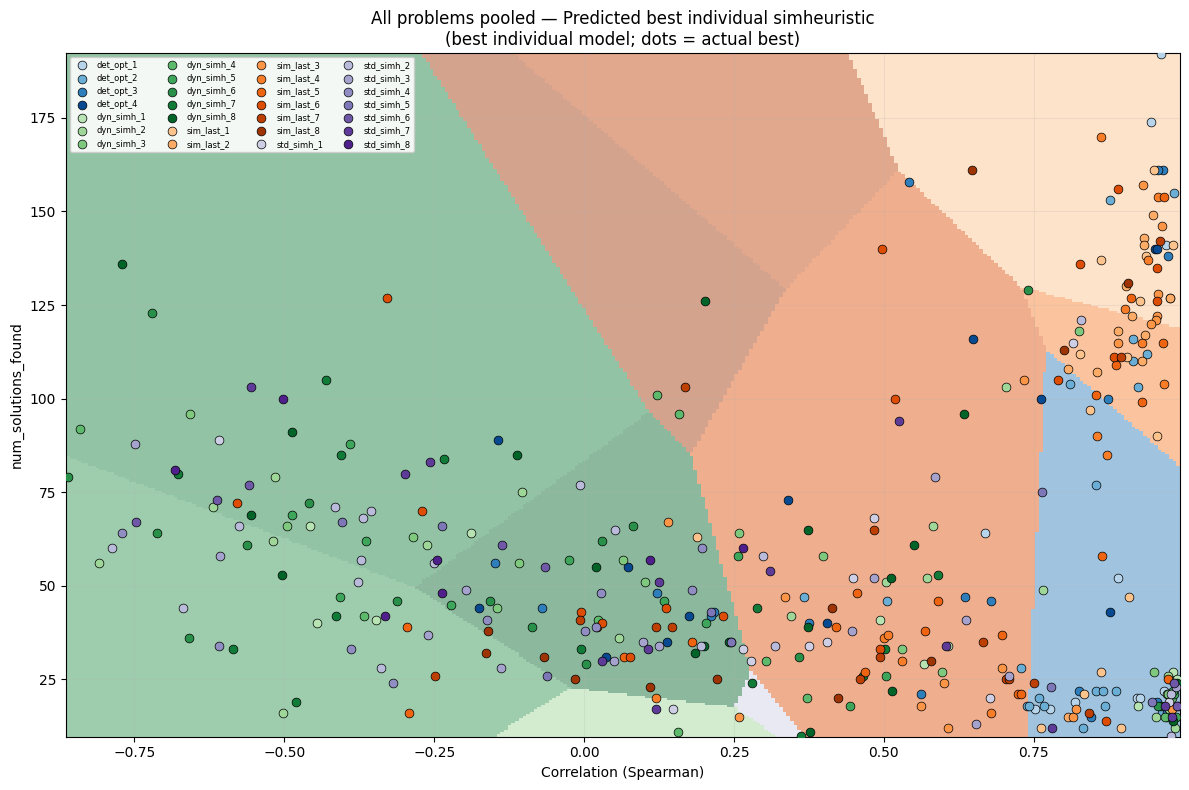

All problems pooled — Actual best simheuristic (400 instances)
              count  percentage
simheuristic                   
det_opt_1        12         3.0
det_opt_2        21         5.2
det_opt_3        18         4.5
det_opt_4        13         3.2
dyn_simh_1       12         3.0
dyn_simh_2       21         5.2
dyn_simh_3       16         4.0
dyn_simh_4       10         2.5
dyn_simh_5       14         3.5
dyn_simh_6       16         4.0
dyn_simh_7       14         3.5
dyn_simh_8       19         4.8
sim_last_1       15         3.8
sim_last_2       12         3.0
sim_last_3       18         4.5
sim_last_4       13         3.2
sim_last_5       20         5.0
sim_last_6       19         4.8
sim_last_7       16         4.0
sim_last_8       12         3.0
std_simh_1       11         2.8
std_simh_2       18         4.5
std_simh_3       15         3.8
std_simh_4       10         2.5
std_simh_5        8         2.0
std_simh_6        7         1.8
std_simh_7       13         3.2
std_simh_

In [16]:
all_simh_all = sorted(fitted_models_all.keys())
color_map_all = _build_algo_colormap(all_simh_all)

corr_min = df_exp_all["correlation"].min()
corr_max = df_exp_all["correlation"].max()
nsf_min = df_exp_all["num_solutions_found"].min()
nsf_max = df_exp_all["num_solutions_found"].max()

n_grid = 300
corr_vals = np.linspace(corr_min, corr_max, n_grid)
nsf_vals = np.linspace(nsf_min, nsf_max, n_grid)
corr_grid, nsf_grid = np.meshgrid(corr_vals, nsf_vals)

X_grid = pd.DataFrame({
    "correlation": corr_grid.ravel(),
    "num_solutions_found": nsf_grid.ravel(),
})
X_grid["corr_per_solution"] = X_grid["correlation"] / X_grid["num_solutions_found"]

sample_model_all = next(iter(fitted_models_all.values()))
feature_names_all = [p for p in sample_model_all.params.index if p != "const"]
X_grid = sm.add_constant(X_grid[feature_names_all])

predictions_all = np.column_stack([
    fitted_models_all[simh].predict(X_grid) for simh in all_simh_all
])
best_simh_idx_all = predictions_all.argmin(axis=1).reshape(corr_grid.shape)

df_best_per_instance_all = (
    df_exp_all.loc[df_exp_all.groupby(["problem_type", "seed"])[dependent_var].idxmin()]
    .copy()
)

cmap = ListedColormap([color_map_all[s] for s in all_simh_all])
fig, ax = plt.subplots(figsize=(12, 8))
ax.pcolormesh(corr_grid, nsf_grid, best_simh_idx_all,
              cmap=cmap, alpha=0.45, shading="auto",
              vmin=0, vmax=len(all_simh_all) - 1)

for simh in all_simh_all:
    subset = df_best_per_instance_all[df_best_per_instance_all["simheuristic"] == simh]
    if subset.empty:
        continue
    ax.scatter(subset["correlation"], subset["num_solutions_found"],
               color=color_map_all[simh], edgecolors="black", linewidths=0.5,
               s=40, zorder=3, label=simh)

ax.set_xlabel("Correlation (Spearman)")
ax.set_ylabel("num_solutions_found")
ax.set_title("All problems pooled — Predicted best individual simheuristic\n"
             "(best individual model; dots = actual best)")
ax.legend(fontsize=6, loc="best", ncol=4, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

n_total_all = len(df_best_per_instance_all)
counts_all = df_best_per_instance_all["simheuristic"].value_counts()
summary_simh_all = pd.DataFrame({
    "count": counts_all,
    "percentage": (counts_all / n_total_all * 100).round(1),
})
summary_simh_all.index.name = "simheuristic"
summary_simh_all = summary_simh_all.reindex(all_simh_all).fillna(0)
summary_simh_all["count"] = summary_simh_all["count"].astype(int)

print(f"{'=' * 55}")
print(f"All problems pooled — Actual best simheuristic ({n_total_all} instances)")
print(f"{'=' * 55}")
print(summary_simh_all.to_string())
print()


# Best algorithm per algorithm group

For each of the four algorithm groups (`det_opt`, `sim_last`, `std_simh`,
`dyn_simh`), we find the individual algorithm that yields the **lowest mean
objective** averaged over all experiments / problems.  These four
representatives are then used in the subsequent analyses.

In [17]:
ALGO_GROUPS = ["det_opt", "sim_last", "std_simh", "dyn_simh"]

# Mean objective per individual algorithm across ALL data
mean_per_simh = (
    df_all.groupby("simheuristic")["mean"]
    .mean()
    .reset_index()
    .rename(columns={"mean": "avg_mean_obj"})
)
mean_per_simh["family"] = mean_per_simh["simheuristic"].apply(_algo_group)

# Pick the best (lowest avg_mean_obj) member from each family
best_per_group = (
    mean_per_simh
    .sort_values("avg_mean_obj")
    .groupby("family")
    .first()
    .reset_index()
)
best_per_group = best_per_group.set_index("family").reindex(ALGO_GROUPS).reset_index()

best_four = best_per_group["simheuristic"].tolist()

print("Best algorithm per algorithm group:")
display(best_per_group[["family", "simheuristic", "avg_mean_obj"]])
print(f"\nSelected representatives: {best_four}")


Best algorithm per algorithm group:


,family,simheuristic,avg_mean_obj
0,det_opt,det_opt_3,11018.660580
1,sim_last,sim_last_6,10654.158390
2,std_simh,std_simh_1,10551.404017
3,dyn_simh,dyn_simh_8,10873.792105



Selected representatives: ['det_opt_3', 'sim_last_6', 'std_simh_1', 'dyn_simh_8']


## Regression table for the four best algorithms

For the four selected algorithms we show the OLS regression coefficients
(predicting `rank` from `correlation` and `num_solutions_found`) pooled
across all experiment groups, together with the adjusted R².  Stars denote
significance: `***` p < 0.001, `**` p < 0.01, `*` p < 0.05.

In [18]:
# --- Regression over all data (pooled across all exp_groups) ---
rows_best = []
for simh in best_four:
    df_s = df_all[df_all["simheuristic"] == simh].copy()
    if df_s.empty:
        continue
    y = df_s[dependent_var]
    X = df_s[[x for x in predictors if x != "const"]]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    row = {"simheuristic": simh, "R²_adj": f"{model.rsquared_adj:.3f}"}
    for pred in predictors:
        row[pred] = _fmt_coef(model.params[pred], model.pvalues[pred])
    rows_best.append(row)

summary_best = pd.DataFrame(rows_best).set_index("simheuristic")
print("Regression over all data (pooled across all exp_groups and problem_types)")
display(summary_best)

from pathlib import Path

# If your notebook runs from experiments/notebooks, this writes to experiments/notebooks/latex
latex_dir = Path("latex")
latex_dir.mkdir(parents=True, exist_ok=True)

# Optional: make table headers a bit cleaner for LaTeX
summary_best_latex = summary_best.copy()
summary_best_latex.index.name = "Simheuristic"

# Optional renaming for prettier math-style header
if "R²_adj" in summary_best_latex.columns:
    summary_best_latex = summary_best_latex.rename(columns={"R²_adj": r"$R^2_{\mathrm{adj}}$"})

tex_str = summary_best_latex.to_latex(
    caption="OLS regression (pooled over all experiment groups and problem types) for selected simheuristics.",
    label="tab:pooled_regression_best_four",
    escape=False,      # keep math in headers and significance markers as-is
    index=True,
    bold_rows=True,
    column_format="l" + "c" * len(summary_best_latex.columns),
    )

tex_path = latex_dir / "pooled_regression_best_four.tex"
tex_path.write_text(tex_str, encoding="utf-8")

print(f"Saved LaTeX table to: {tex_path}")



Regression over all data (pooled across all exp_groups and problem_types)


,R²_adj,const,correlation,num_solutions_found
simheuristic,,,,
det_opt_3,0.228,16.1113***,-7.1357***,-0.0093
sim_last_6,0.069,13.4081***,-3.4649***,-0.0104
std_simh_1,0.021,11.3123***,1.5823*,0.0148
dyn_simh_8,0.139,10.5984***,5.1452***,0.0046


Saved LaTeX table to: latex\pooled_regression_best_four.tex


## Results table for the four best methods (all experiment groups)

This table follows the same format as `param_tuning_det_opt.ipynb`.
The four columns represent the four experiment groups:

| Column 1 | Column 2 | Column 3 | Column 4 |
|---|---|---|---|
| w/o tardiness, p = 0.3 | w/o tardiness, p = 1.0 | w/ tardiness, p = 0.3 | w/ tardiness, p = 1.0 |

For each `(problem, method)` pair we report the **mean objective** across
seeds, mark the best in bold, add significance superscripts (paired t-test
with Šidák correction), and the percentage of seeds where each method was
best.

In [19]:

# Desired column order for the final table
TABLE_EXP_GROUPS = [
    "p = 0.3 | no_tardiness",
    "p = 1.0 | no_tardiness",
    "p = 0.3 | with_tardiness",
    "p = 1.0 | with_tardiness",
]

# Significance level and Šidák correction for (n_methods choose 2) = 6 tests
_alpha = 0.05
_n_pair_tests = len(best_four) * (len(best_four) - 1) // 2
_alpha_cor = 1 - (1 - _alpha) ** (1 / _n_pair_tests)

# ---- Build summary, significance, % best per (exp_group, problem) --------
_summaries: dict = {}      # {problem: {exp_group: DataFrame indexed by simheuristic}}
_sig_better: dict = {}     # {exp_group: {problem: {method: [worse_methods]}}}
_pct_best: dict = {}       # {exp_group: {problem: {method: pct}}}

for exp_group in TABLE_EXP_GROUPS:
    df_eg = df_all[df_all["exp_group"] == exp_group].copy()
    _sig_better[exp_group] = {}
    _pct_best[exp_group] = {}

    for problem_name in problem_order:
        problem_type = problem_type_for_group(problem_name, exp_group)
        df_prob = df_eg[df_eg["problem_type"] == problem_type].copy()
        df_prob = df_prob[df_prob["simheuristic"].isin(best_four)]

        # Mean objective per method
        summary = (
            df_prob.groupby("simheuristic")[["mean"]]
            .mean()
            .round(2)
            .reindex(best_four)
        )
        summary.columns = pd.MultiIndex.from_product([[exp_group], summary.columns])
        _summaries.setdefault(problem_name, {})[exp_group] = summary

        # Pivot for paired tests
        pivot = df_prob.pivot(index="seed", columns="simheuristic", values="mean")
        pivot = pivot.reindex(columns=best_four)

        # Significance
        sig = {m: [] for m in best_four}
        means = df_prob.groupby("simheuristic")["mean"].mean()
        for i, m1 in enumerate(best_four):
            for m2 in best_four[i + 1:]:
                if m1 not in pivot.columns or m2 not in pivot.columns:
                    continue
                vals1 = pivot[m1].dropna()
                vals2 = pivot[m2].dropna()
                common_idx = vals1.index.intersection(vals2.index)
                if len(common_idx) < 2:
                    continue
                _, p = _ttest_rel(vals1.loc[common_idx], vals2.loc[common_idx])
                if p < _alpha_cor:
                    if means[m1] < means[m2]:
                        sig[m1].append(m2)
                    else:
                        sig[m2].append(m1)
        _sig_better[exp_group][problem_name] = sig

        # % best
        pct = {m: 0.0 for m in best_four}
        n_seeds = len(pivot.index)
        for seed in pivot.index:
            min_val = pivot.loc[seed].min()
            winners = pivot.loc[seed][pivot.loc[seed] == min_val].index.tolist()
            for w in winners:
                pct[w] += 100.0 / n_seeds
        _pct_best[exp_group][problem_name] = pct

# ---- Merge into one big DataFrame per problem --------------------------
_combined: dict = {}
for problem_name in problem_order:
    dfs_to_cat = []
    for eg in TABLE_EXP_GROUPS:
        dfs_to_cat.append(_summaries[problem_name][eg])
    _combined[problem_name] = pd.concat(dfs_to_cat, axis=1)

# ---- Display nicely (plain) --------------------------------------------
for problem_name in problem_order:
    print(f"\n{'=' * 80}")
    print(f"Problem: {problem_name}")
    print(f"{'=' * 80}")
    display(_combined[problem_name])



Problem: OpenShop


,p = 0.3 | no_tardiness,p = 1.0 | no_tardiness,p = 0.3 | with_tardiness,p = 1.0 | with_tardiness
,mean,mean,mean,mean
simheuristic,,,,
det_opt_3,8353.06,8940.78,13013.42,26240.41
sim_last_6,8335.31,8918.32,12211.80,23980.20
std_simh_1,8410.47,9041.95,10774.31,22111.34
dyn_simh_8,8447.17,8962.21,9965.70,22488.76



Problem: ParallelMachines


,p = 0.3 | no_tardiness,p = 1.0 | no_tardiness,p = 0.3 | with_tardiness,p = 1.0 | with_tardiness
,mean,mean,mean,mean
simheuristic,,,,
det_opt_3,78.73,78.56,182.94,341.48
sim_last_6,77.46,79.39,159.91,341.41
std_simh_1,77.29,82.22,148.28,323.33
dyn_simh_8,76.07,77.83,142.69,290.14



Problem: HybridFlowShop


,p = 0.3 | no_tardiness,p = 1.0 | no_tardiness,p = 0.3 | with_tardiness,p = 1.0 | with_tardiness
,mean,mean,mean,mean
simheuristic,,,,
det_opt_3,156.42,167.32,542.49,714.91
sim_last_6,156.64,166.94,302.94,515.74
std_simh_1,156.65,167.26,299.24,476.49
dyn_simh_8,156.78,166.87,266.57,387.63



Problem: JobShop


,p = 0.3 | no_tardiness,p = 1.0 | no_tardiness,p = 0.3 | with_tardiness,p = 1.0 | with_tardiness
,mean,mean,mean,mean
simheuristic,,,,
det_opt_3,12328.05,12914.07,32289.65,77133.48
sim_last_6,12369.55,12956.02,31457.91,73921.49
std_simh_1,12487.36,13105.45,31923.28,73283.55
dyn_simh_8,12602.58,13113.99,33190.07,73084.71



Problem: FlexibleJobShop


,p = 0.3 | no_tardiness,p = 1.0 | no_tardiness,p = 0.3 | with_tardiness,p = 1.0 | with_tardiness
,mean,mean,mean,mean
simheuristic,,,,
det_opt_3,150.31,158.85,6664.50,19923.79
sim_last_6,150.14,159.30,6214.77,20607.95
std_simh_1,150.80,160.20,7171.88,20676.72
dyn_simh_8,154.30,166.23,8603.59,25131.94


### LaTeX table

In [20]:
# Labels (from central notation)
_lbl_problem = "\\textbf{Problem}"
_lbl_method = "\\textbf{Method}"
_lbl_mean = "\\textbf{Mean obj.}"

# Map used for column headers (underlined+bold) and row labels
_latex_map = {
    k: LATEX_NOTATION[k]
    for k in ["FlexibleJobShop", "HybridFlowShop", "JobShop",
              "ParallelMachines", "OpenShop"]
}
_latex_map.update({
    eg: LATEX_NOTATION[eg + "__header"]
    for eg in TABLE_EXP_GROUPS
})

# Build a nice name for each of the best_four methods
_method_latex = {}
for simh in best_four:
    fam = _algo_group(simh)
    num = simh.split("_")[-1]
    _method_latex[simh] = f"{LATEX_NOTATION.get(fam, fam)}~{num}"

# Numerals for significance superscripts (1-indexed by position in best_four)
_method_numerals = {simh: str(i + 1) for i, simh in enumerate(best_four)}

# Build merged DataFrame
_merged_list = []
for problem_name in problem_order:
    cdf = _combined[problem_name].copy()
    cdf[_lbl_problem] = problem_name
    _merged_list.append(cdf)

_df_merged = pd.concat(_merged_list)
_df_merged.reset_index(inplace=True)
_df_merged.rename(columns={"simheuristic": _lbl_method}, inplace=True)

# Rename columns
_df_merged.columns = pd.MultiIndex.from_tuples([
    (
        _latex_map.get(c0, c0),
        "\\textbf{Mean obj.}" if c1 == "mean" else c1,
    )
    for c0, c1 in _df_merged.columns
])

# Rename index entries
_df_merged[(_lbl_problem, "")] = _df_merged[(_lbl_problem, "")].map(
    lambda x: _latex_map.get(x, x)
)
_df_merged[(_lbl_method, "")] = _df_merged[(_lbl_method, "")].map(
    lambda x: _method_latex.get(x, x)
)

_df_merged.set_index([(_lbl_problem, ""), (_lbl_method, "")], inplace=True)
_df_merged.index.names = [_lbl_problem, _lbl_method]

# --- Bold best, add significance / % best, AND add data bars ---
_inv_method_latex = {v: k for k, v in _method_latex.items()}
_inv_latex_map = {v: k for k, v in _latex_map.items()}

# First pass: collect raw numeric values per (problem, exp_group) for bar scaling
_raw_vals: dict = {}  # (prob_label, col) -> {meth_label: float}
for col in _df_merged.columns:
    for prob_label in _df_merged.index.get_level_values(0).unique():
        sub = _df_merged.loc[prob_label, col]
        _raw_vals[(prob_label, col)] = {
            meth: float(v) for meth, v in sub.items()
        }

# Second pass: format cells with bold + significance + %best + bar
for col_eg_label, col_metric_label in _df_merged.columns:
    col = (col_eg_label, col_metric_label)
    raw_eg = _inv_latex_map.get(col_eg_label, col_eg_label)

    for prob_label in _df_merged.index.get_level_values(0).unique():
        vals_dict = _raw_vals[(prob_label, col)]
        group_vals = list(vals_dict.values())
        group_min = min(group_vals)
        group_max = max(group_vals)

        for meth_label in _df_merged.loc[prob_label].index:
            raw_problem = _inv_latex_map.get(prob_label, prob_label)
            raw_method = _inv_method_latex.get(meth_label, meth_label)
            v = vals_dict[meth_label]

            is_best = (v == group_min)

            # Significance superscripts
            worse = _sig_better.get(raw_eg, {}).get(raw_problem, {}).get(raw_method, [])
            sup_str = ""
            if worse:
                syms = ",".join(_method_numerals[m] for m in worse)
                sup_str = f"^{{({syms})}}"

            # % best
            pct = _pct_best.get(raw_eg, {}).get(raw_problem, {}).get(raw_method, 0.0)
            sub_str = f"_{{({pct:.0f}\\%)}}"

            # Number string (bold if best)
            num_str = f"{v:.2f}"
            if is_best:
                num_str = f"\\textbf{{{num_str}}}"

            # Combine number + super/subscripts
            cell_text = num_str + f"${sup_str}{sub_str}$"

            # Optionally wrap in a data bar
            if LATEX_SHOW_BARS:
                if group_max == 0:
                    bar_w = 0.0
                else:
                    bar_w = (v / group_max) * _BAR_FULL_WIDTH_CM
                bar = (
                    f"\\rlap{{\\color{{{_BAR_COLOR}}}"
                    f"\\rule{{{bar_w:.3f}cm}}{{{_BAR_HEIGHT}}}}}"
                )
                formatted = f"\\makebox[{_CELL_WIDTH_CM}cm][l]{{{bar}{cell_text}}}"
            else:
                formatted = cell_text

            _df_merged.loc[(prob_label, meth_label), col] = formatted

print("Final table for the four best methods:")
display(_df_merged)

# ---- Export to LaTeX ----
_caption = (
    "Summary results for the best representative of each algorithm group. "
    "Columns show four experimental settings: w/o and w/ tardiness $\\times$ partial ($p{=}0.3$) "
    "and full ($p{=}1.0$) stochasticity. "
    "Best values marked in \\textbf{bold}. "
    + ("Background bars are proportional to the group maximum per problem for quick visual comparison. " if LATEX_SHOW_BARS else "") +
    "Significance superscripts (paired $t$-test, \\v{S}id\\'{a}k corrected): "
)
_caption += ", ".join(
    f"${_method_numerals[s]}$ -- {_tex_escape(_method_latex[s])}" for s in best_four
)
_caption += ". Percentage in subscript indicates how often the method was best across seeds."

_col_fmt = "ll" + "|c" * len(TABLE_EXP_GROUPS)
_latex_out = _df_merged.to_latex(
    index=True,
    multirow=True,
    multicolumn=True,
    multicolumn_format="c",
    escape=False,
    caption=_caption,
    column_format=_col_fmt,
    label="tab:best_four_methods_all_settings",
)
_latex_out = _latex_out.replace("\\begin{table}", "\\begin{table}[ht!]\n\\centering")

LATEX_DIR = Path("latex")
LATEX_DIR.mkdir(parents=True, exist_ok=True)
_tex_path = LATEX_DIR / "best_four_methods_all_settings.tex"
with open(_tex_path, "w", encoding="utf-8") as _f:
    _f.write(_latex_out)
print(f"\nSaved LaTeX table to: {_tex_path}")


Final table for the four best methods:


C:\Users\jbt640\AppData\Local\Temp\ipykernel_14624\2240338357.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8353.06$^{(4)}_{(40\%)}$' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _df_merged.loc[(prob_label, meth_label), col] = formatted
C:\Users\jbt640\AppData\Local\Temp\ipykernel_14624\2240338357.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8940.78$^{(3)}_{(45\%)}$' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  _df_merged.loc[(prob_label, meth_label), col] = formatted
C:\Users\jbt640\AppData\Local\Temp\ipykernel_14624\2240338357.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13013.42$_{(0\%)}$' has dtype incompatible with float

\underline{\textbf{w/o tard., $p{=}0.3$}}  \
                                                        \textbf{Mean obj.}   
\textbf{Problem} \textbf{Method}                                             
OS               Det.~opt.~3                      8353.06$^{(4)}_{(40\%)}$   
                 Sim-last~6              \textbf{8335.31}$^{(4)}_{(40\%)}$   
                 Std.~simh.~1                           8410.47$_{(15\%)}$   
                 Dyn.~simh.~8                            8447.17$_{(5\%)}$   
PM               Det.~opt.~3                              78.73$_{(15\%)}$   
                 Sim-last~6                               77.46$_{(15\%)}$   
                 Std.~simh.~1                             77.29$_{(25\%)}$   
                 Dyn.~simh.~8                    \textbf{76.07}$_{(45\%)}$   
HFS              Det.~opt.~3                    \textbf{156.42}$_{(30\%)}$   
                 Sim-last~6                              156.64$_{(20\%)}$   
                 Std.~simh.~1                            156.65$_{(15\%)}$   
                 Dyn.~simh.~8                            156.78$_{(35\%)}$   
JS               Det.~opt.~3          \textbf{12328.05}$^{(3,4)}_{(60\%)}$   
                 Sim-last~6                    12369.55$^{(3,4)}_{(35\%)}$   
                 Std.~simh.~1                     12487.36$^{(4)}_{(5\%)}$   
                 Dyn.~simh.~8                           12602.58$_{(0\%)}$   
FJS              Det.~opt.~3                       150.31$^{(4)}_{(35\%)}$   
                 Sim-last~6               \textbf{150.14}$^{(4)}_{(40\%)}$   
                 Std.~simh.~1                      150.80$^{(4)}_{(25\%)}$   
                 Dyn.~simh.~8                             154.30$_{(0\%)}$   

                                 \underline{\textbf{w/o tard., $p{=}1.0$}}  \
                                                        \textbf{Mean obj.}   
\textbf{Problem} \textbf{Method}                                             
OS               Det.~opt.~3                      8940.78$^{(3)}_{(45\%)}$   
                 Sim-last~6              \textbf{8918.32}$^{(3)}_{(20\%)}$   
                 Std.~simh.~1                            9041.95$_{(0\%)}$   
                 Dyn.~simh.~8                           8962.21$_{(35\%)}$   
PM               Det.~opt.~3                        78.56$^{(3)}_{(40\%)}$   
                 Sim-last~6                               79.39$_{(20\%)}$   
                 Std.~simh.~1                              82.22$_{(5\%)}$   
                 Dyn.~simh.~8              \textbf{77.83}$^{(3)}_{(35\%)}$   
HFS              Det.~opt.~3                             167.32$_{(25\%)}$   
                 Sim-last~6                              166.94$_{(20\%)}$   
                 Std.~simh.~1                            167.26$_{(20\%)}$   
                 Dyn.~simh.~8                   \textbf{166.87}$_{(35\%)}$   
JS               Det.~opt.~3          \textbf{12914.07}$^{(3,4)}_{(50\%)}$   
                 Sim-last~6                    12956.02$^{(3,4)}_{(35\%)}$   
                 Std.~simh.~1                          13105.45$_{(10\%)}$   
                 Dyn.~simh.~8                           13113.99$_{(5\%)}$   
FJS              Det.~opt.~3              \textbf{158.85}$^{(4)}_{(50\%)}$   
                 Sim-last~6                        159.30$^{(4)}_{(30\%)}$   
                 Std.~simh.~1                      160.20$^{(4)}_{(20\%)}$   
                 Dyn.~simh.~8                             166.23$_{(0\%)}$   

                                 \underline{\textbf{w/ tard., $p{=}0.3$}}  \
                                                       \textbf{Mean obj.}   
\textbf{Problem} \textbf{Method}                                            
OS               Det.~opt.~3                           13013.42$_{(0\%)}$   
                 Sim-last~6                            12211.80$_{(0\%)}$   
                 Std.~simh.~1                 10774.31$^{(


Saved LaTeX table to: latex\best_four_methods_all_settings.tex
